# 밴드형 예측 하이브리드 파이프라인 — 베이스라인 선정(5종) → `B* + CatBoost` (BackTest)

> **목표** : 통계적 불확실성을 포함한 **밴드형(P10·P50·P90) 예측 시나리오**를 산출하는 하이브리드 파이프라인을
> 구축한다. **베이스라인 5종을 겨뤄 최우수 B\* 를 선정**하고, 그 B\* 를 **CatBoost 로 부스팅**한 효과를
> **Before vs After** 로 공정하게 비교 검증한다.
>
> $$\text{5종 비교}\;\{\text{RandomWalk, SeasonalNaive, AR, BAR, BAR-X}\}\;\rightarrow\;B^{*}\;\rightarrow\;B^{*}+\text{CatBoost}\;\rightarrow\;+\text{Bootstrap(밴드)}$$

## 파이프라인 한눈에 — 각 셀 = 한 단계

| Phase | 단계 | 하는 일 | 산출 |
|---|---|---|---|
| **0** | 환경·CONFIG·라우팅 | 하이퍼파라미터 분리, depth 라벨 파싱, 단지별 시계열 + 전역 패널 적재 | `module0/` |
| **1** | 베이스라인 선정 | 5종(RandomWalk·SeasonalNaive·AR·BAR·BAR-X) · 전체 단지 **3윈도우(8년 train/2년 backtest)** 우위카운트 → **B\*** | `module1/` |
| **2** | B\* + CatBoost | B\* 잔차를 전역 CatBoost 로 보정 · **마지막에 부트스트랩으로 밴드** · 현실성필터 · **Before vs After** | `module2/` |
| **3** | 설명·피처선택 | SHAP Summary · `FEATURE_DROP_THRESHOLD` 로 저기여 피처 제거 | `module3/` |

## 설계 원칙 (기존 참조 노트북과 **다른** 점)

1. **베이스라인 선정이 먼저** : 5종을 같은 무대에서 점예측 RMSE·WAPE 로 겨뤄 **전역 단일 B\*** 를 고른다.
   부트스트랩한 BAR-X 를 별도 Challenger 로 두지 않는다(순서상 부적합) → B\* 는 베이스라인 후보의 하나.
2. **부트스트랩이 파이프라인 *마지막*** 에 위치한다.
   $$\text{점예측}(B^{*}) \;\rightarrow\; \text{잔차 보정(CatBoost)} \;\rightarrow\; \textbf{마지막에 부트스트랩으로 밴드 생성}$$
   → "점예측 성능"과 "밴드(불확실성) 품질"을 단계적으로 분리해 채점한다.
3. **CatBoost 는 전체 단지 패널에 학습** 한다. 단지별 B\* 잔차를 타깃으로,
   `Static__`(건설사등급·평수구분 등 categorical) + `depth1/2/3`(거시·권역·구별) 피처로
   **단지 간 횡단면 차이**를 학습한다. (단일 단지 안에서 분산 0이던 `Static__` 이 패널에서 신호가 됨)
4. **시간 누수(leakage) 차단** : 메인 학습 패널을 예측구간 직전(`TRAIN_END`)에서 **공통 컷오프**.
   (단, B\* 선정은 모델 '계열' 선택이므로 컷오프 없는 전체 패널의 3윈도우 백테스트로 수행)
5. **현실성 필터 유지** : 통계적으론 가능해도 경제적으로 말이 안 되는 경로는 분포에서 **제거(drop)**.
6. **Header_ 컬럼은 식별자** : `시/구/동/Timestamp/단지명/평형` 은 행 식별·정렬·조인 용도이며 **피처가 아니다**.

## Phase 0-A. 실행 환경 · 임포트

- 통계 파이프라인(AR/BAR-X/부트스트랩) : `numpy`·`scipy`·`statsmodels` 의 **CPU** 연산.
- **CatBoost GPU** : CatBoost 의 GPU 가속은 **CUDA(NVIDIA) 전용** 이다. DirectML/AMD 는 지원하지 않는다.
  → `task_type` 을 자동 감지한다: CUDA GPU 가 보이면 `GPU`, 아니면 `CPU`.
  (이 환경은 AMD Radeon 내장그래픽 → 자동으로 `CPU` 로 동작. 다른 환경에선 자동으로 GPU 사용)

In [111]:
# --- [Windows/인코딩 필수 설정 — 다른 import 보다 먼저] ---
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("PYTHONUTF8", "1")
os.environ.setdefault("PYTHONIOENCODING", "utf-8:replace")
os.environ.setdefault("PYTHONWARNINGS", "ignore")

import re
import sys
import glob
import json
import warnings
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from catboost import CatBoostRegressor, Pool


def detect_catboost_task_type() -> str:
    """CatBoost GPU(CUDA) 가용 여부 자동 감지. CUDA GPU가 보이면 'GPU', 아니면 'CPU'.
    CatBoost GPU는 CUDA 전용이라 DirectML/AMD에서는 항상 'CPU'가 된다."""
    try:
        from catboost.utils import get_gpu_device_count
        n = get_gpu_device_count()
        return "GPU" if n and n > 0 else "CPU"
    except Exception:
        return "CPU"


CATBOOST_TASK_TYPE = detect_catboost_task_type()
print(f"[env] python={sys.version.split()[0]}  numpy={np.__version__}  pandas={pd.__version__}")
print(f"[env] CatBoost task_type = {CATBOOST_TASK_TYPE}"
      + ("  (CUDA GPU 감지됨)" if CATBOOST_TASK_TYPE == "GPU" else "  (CUDA 없음 → CPU. AMD/DirectML은 CatBoost GPU 미지원)"))

[env] python=3.11.3  numpy=2.4.4  pandas=3.0.3
[env] CatBoost task_type = CPU  (CUDA 없음 → CPU. AMD/DirectML은 CatBoost GPU 미지원)


## Phase 0-B. `GLOBAL_CONFIG` — 모든 하이퍼파라미터를 한 곳에

하드코딩을 금지하고, 각 값에 **통계적/휴리스틱 근거**를 주석으로 남긴다.
단지·평형·기간만 바꾸면 다른 백테스트로 즉시 전환된다.

In [112]:
# 워크스페이스 루트 자동 탐지 (노트북 cwd가 ml_pipeline/ 이어도 동작)
def _find_workspace_root() -> str:
    p = Path.cwd().resolve()
    for cand in [p, *p.parents]:
        if (cand / "meta_ml" / "output").exists():
            return str(cand)
    return str(p)


WORKSPACE_ROOT = _find_workspace_root()


@dataclass
class GlobalConfig:
    # ---- 경로 (워크스페이스 루트 기준 절대경로) ----
    PANEL_ROOT: str = os.path.join(WORKSPACE_ROOT, "meta_ml", "output", "서울특별시")  # 전체 단지 패널 루트
    OUT_ROOT: str = os.path.join(WORKSPACE_ROOT, "ml_pipeline")                       # 중간 산출물 module0~3 상위

    # ---- 백테스트 대상 (구별 1개, 데이터 최장 평형) ----
    # (구, 동, 단지명, 파일평형) — 파라미터화: 여기만 바꾸면 대상 변경
    TARGETS: tuple = (
        ("강남구", "압구정동", "현대6,7차", "129.92"),
        ("강동구", "암사동", "강동롯데캐슬퍼스트", "84.81"),
        ("마포구", "아현동", "마포래미안푸르지오", "84.59"),
        ("서초구", "반포동", "래미안퍼스티지", "84.76"),
        ("송파구", "잠실동", "잠실주공5단지", "82.61"),
    )

    # ---- 공통 고정 기간 (월초 'YYYY-MM-01') ----
    TRAIN_START: str = "2016-06-01"  # Train 시작
    TRAIN_END:   str = "2023-05-01"  # 학습 마지막 월 (포함). 96개월 = 8년
    TEST_START:  str = "2023-06-01"  # 예측 시작
    TEST_END:    str = "2025-05-01"  # 예측 마지막 (포함). 24개월 = 2년

    # ---- 데이터 가드 ----
    MIN_TRAIN_MONTHS: int = 36   # 36개월 미만이면 시계열/계절성 추정 불안정 → 단지 제외
    HORIZON: int = 24            # 예측 지평 = TEST 길이 (2년). TEST 구간에서 자동 검증

    # ---- 타깃 변환 ----
    LOG_TARGET: bool = True      # 로그공간 모델링: 가격 분산 비일정성 완화 + 음수가격 원천 차단

    # ---- AR (베이스라인 후보 & B* 점예측) ----
    AR_MAX_LAG: int = 12         # 후보 최대 차수(월 데이터 → 1년). 과대차수는 과적합/분산팽창
    AR_IC: str = "aic"           # 차수 선택 기준: 'aic'(예측지향) 또는 'bic'(간결성↑)
    SEASONAL_PERIOD: int = 12    # 월별 데이터의 계절 주기(연 단위)

    # ---- TSCV (시계열 교차검증, 베이스라인 비교) ----
    TSCV_FOLDS: int = 4          # rolling-origin 폴드 수. 학습구간 내 4개 시점에서 검증
    TSCV_VAL_HORIZON: int = 12   # 각 폴드 검증 지평(개월). 1년 앞 예측 정확도로 채점

    # ---- CatBoost (전역 잔차 학습) ----
    CB_ITERATIONS: int = 800     # 부스팅 라운드. early stopping과 함께 상한
    CB_LEARNING_RATE: float = 0.03  # 작은 lr + 많은 iter = 일반화 안정
    CB_DEPTH: int = 6            # 트리 깊이. 6은 표형 데이터 기본 권장값
    CB_L2_LEAF_REG: float = 3.0 # L2 정규화(과적합 억제)
    CB_EARLY_STOP: int = 50      # 검증 손실 50라운드 정체 시 조기종료
    CB_RANDOM_SEED: int = 42
    PANEL_AR_MAX_LAG: int = 6    # 전역 패널 잔차 산출용 AR 최대차수(속도/정직 균형). 단지별 AIC 선택
    ORIGIN_STRIDE: int = 12      # h스텝 오차 학습: 롤링 예측원점 간격(개월). 여러 거시레짐 커버
    INCLUDE_HSTEP_FEATURE: bool = True  # 예측지평 h를 피처로 추가(오차분산은 h에 따라 커짐)
    AR_FORECAST_GUARD: float = 3.0   # AR 외삽 안정성 가드: 예측이 학습마지막 로그값에서 ±3.0 초과 발산하면 폭발근→해당원점 제외
    ERR_CLIP_LOG: float = 1.0        # h스텝 로그오차 |e|>1.0(≈±172%)은 수치/경제 이상치 → 제외

    # ---- BAR-X (Bayesian AR-X, 베이스라인 후보) ----
    BARX_MAX_LAG: int = 4        # AR-X 자기시차 상한(월 데이터, 단변량). 과대시차는 계수 폭증
    MINNESOTA_LAMBDA: float = 0.2  # Minnesota prior 전체 수축 강도(작을수록 강수축=RandomWalk쪽)
    MINNESOTA_THETA: float = 0.5   # 외생(타변수) 교차수축 강도 θ. 외생계수 prior분산=(λθ)²·σ²/σ_x²
    BARX_FREEZE_EXOG: bool = True   # 외생변수(거시·규제) 미래 동결(conditional forecast)

    # ---- 부트스트랩 (밴드 — 파이프라인 마지막) ----
    N_BOOTSTRAP: int = 1000      # 시나리오 경로 수. 1000이면 P10/P90 분위 안정
    BLOCK_SIZE: int = 3          # 블록 부트스트랩 블록 길이(개월). 자기상관 보존
    QUANTILES: tuple = (0.1, 0.5, 0.9)  # 밴드 분위 (P10·P50·P90)
    BOOTSTRAP_SEED: int = 42
    PI_ALPHA: float = 0.2        # 예측구간 유의수준. P10~P90 = 80% 구간 → α=0.2 (Winkler용)

    # ---- 현실성 필터 ----
    REALISM_MAX_MOM: float = 0.25   # 월간 변동률 |Δ|>25%면 비현실 경로로 간주(주택 월변동 한계)
    REALISM_DROP: bool = True       # 위반 경로를 분포에서 제거(drop). False면 리포트만

    # ---- 피처 선택 (Phase 3) ----
    FEATURE_DROP_THRESHOLD: float = 0.005  # 정규화 SHAP 중요도 < 0.5%면 저기여 피처로 제거 후보

    # ---- 식별자(피처 아님) ----
    HEADER_COLS: tuple = (
        "Header_시", "Header_구", "Header_동", "Header_Timestamp", "Header_단지명", "Header_평형",
    )
    TARGET_COL: str = "target"
    TIME_COL: str = "Header_Timestamp"


CFG = GlobalConfig()
for _m in range(4):
    Path(CFG.OUT_ROOT, f"module{_m}").mkdir(parents=True, exist_ok=True)
print("[cfg] 학습", CFG.TRAIN_START, "~", CFG.TRAIN_END, "| 예측", CFG.TEST_START, "~", CFG.TEST_END)
print("[cfg] 대상 단지:", len(CFG.TARGETS), "개 | task_type:", CATBOOST_TASK_TYPE)

[cfg] 학습 2016-06-01 ~ 2023-05-01 | 예측 2023-06-01 ~ 2025-05-01
[cfg] 대상 단지: 5 개 | task_type: CPU


## Phase 0-C. depth 라벨 파싱 — 피처 그룹화

컬럼 접두사로 의미 계층을 분리한다.

| 그룹 | 접두사 | 의미 | 시간변동 |
|---|---|---|---|
| `D1_Macro` | `depth1__` | 전국 거시 (기준금리·CPI·M2·실업률 등) | O |
| `D2_Region` | `depth2__` | 권역 수급 (매매/전세/월세 수급동향) | O |
| `D3_RegionGu` | `depth3__` | 구별 (매매·전세지수 + 정책 레짐) | O |
| `Static` | `Static__` | 단지 정적 속성 (건설사·평수·세대수 등) | X (단지 내 불변) |

`Static__` 은 CatBoost categorical 피처로 쓰고, `D1~D3` 은 수치 피처로 쓴다.
`Header_*` 와 `target` 은 피처에서 제외한다.

In [113]:
DEPTH_PATTERNS = {
    "D1_Macro":    re.compile(r"^depth1__"),
    "D2_Region":   re.compile(r"^depth2__"),
    "D3_RegionGu": re.compile(r"^depth3__"),
    "Static":      re.compile(r"^Static__"),
}


def group_columns(columns: List[str]) -> Dict[str, List[str]]:
    """컬럼명을 의미 그룹으로 분류. Header_/target 은 어디에도 넣지 않는다."""
    groups: Dict[str, List[str]] = {k: [] for k in DEPTH_PATTERNS}
    groups["Header"] = []
    groups["Target"] = []
    for c in columns:
        if c == CFG.TARGET_COL:
            groups["Target"].append(c); continue
        if c.startswith("Header_"):
            groups["Header"].append(c); continue
        matched = False
        for g, pat in DEPTH_PATTERNS.items():
            if pat.match(c):
                groups[g].append(c); matched = True; break
        if not matched:
            groups.setdefault("Other", []).append(c)
    return groups


def feature_columns(columns: List[str]) -> Tuple[List[str], List[str]]:
    """CatBoost 입력용 (수치피처, 범주피처) 반환.
    수치 = D1+D2+D3, 범주 = Static. Header/target 제외."""
    g = group_columns(columns)
    numeric = g["D1_Macro"] + g["D2_Region"] + g["D3_RegionGu"]
    categorical = g["Static"]
    return numeric, categorical


# Static 중 본래 수치형(역세권수·호재수)은 categorical로 강제하지 않도록 분리
STATIC_NUMERIC_HINT = {"Static__역세권수", "Static__호재수"}
print("[parse] depth 그룹 정규식 준비 완료:", list(DEPTH_PATTERNS.keys()))

[parse] depth 그룹 정규식 준비 완료: ['D1_Macro', 'D2_Region', 'D3_RegionGu', 'Static']


## Phase 0-D. 데이터 라우팅

두 종류의 데이터를 만든다.

1. **단지별 시계열** (AR / BAR-X 입력) — 백테스트 5개 단지 각각. 시간 오름차순 정렬, 학습/예측 분리.
2. **전역 패널** (CatBoost 입력) — `meta_ml` 전체 단지×평형. **공통 컷오프**(`TRAIN_END` 이하)만 남겨 누수 차단.

원본 CSV 는 최신→과거 **내림차순** 이므로 반드시 `Header_Timestamp` 로 **오름차순 재정렬**한다.

In [114]:
def _target_path(gu: str, dong: str, name: str, pyeong: str) -> str:
    return os.path.join(CFG.PANEL_ROOT, gu, dong, f"{name}_{pyeong}.csv")


def load_complex_series(gu, dong, name, pyeong) -> pd.DataFrame:
    """단일 단지×평형 CSV 적재 → 시간 오름차순 정렬 + Timestamp index."""
    path = _target_path(gu, dong, name, pyeong)
    df = pd.read_csv(path, encoding="utf-8-sig")
    df[CFG.TIME_COL] = pd.to_datetime(df[CFG.TIME_COL])
    df = df.sort_values(CFG.TIME_COL).reset_index(drop=True)  # 내림차순 원본 → 오름차순
    return df


def split_train_test(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """공통 고정 구간으로 학습/예측 분리."""
    t = df[CFG.TIME_COL]
    train = df[(t >= CFG.TRAIN_START) & (t <= CFG.TRAIN_END)].reset_index(drop=True)
    test = df[(t >= CFG.TEST_START) & (t <= CFG.TEST_END)].reset_index(drop=True)
    return train, test


# --- 1) 백테스트 단지별 시계열 적재 ---
series_store: Dict[str, dict] = {}
for gu, dong, name, pyeong in CFG.TARGETS:
    df = load_complex_series(gu, dong, name, pyeong)
    train, test = split_train_test(df)
    key = f"{gu}|{name}_{pyeong}"
    if len(train) < CFG.MIN_TRAIN_MONTHS:
        print(f"[skip] {key} 학습 {len(train)}개월 < {CFG.MIN_TRAIN_MONTHS} → 제외")
        continue
    series_store[key] = {"gu": gu, "dong": dong, "name": name, "pyeong": pyeong,
                          "full": df, "train": train, "test": test}
    print(f"[load] {key:30s} train={len(train):3d}개월  test={len(test):3d}개월")

print(f"\n[load] 백테스트 단지 {len(series_store)}개 적재 완료")

[load] 강남구|현대6,7차_129.92              train= 84개월  test= 24개월
[load] 강동구|강동롯데캐슬퍼스트_84.81            train= 84개월  test= 24개월
[load] 마포구|마포래미안푸르지오_84.59            train= 84개월  test= 24개월
[load] 서초구|래미안퍼스티지_84.76              train= 84개월  test= 24개월
[load] 송파구|잠실주공5단지_82.61              train= 84개월  test= 24개월

[load] 백테스트 단지 5개 적재 완료


In [115]:
def load_global_panel(cutoff_end: str) -> pd.DataFrame:
    """meta_ml 전체 단지×평형을 하나의 패널로 적재.
    누수 차단: Header_Timestamp <= cutoff_end (TRAIN_END) 인 행만 남긴다."""
    paths = glob.glob(os.path.join(CFG.PANEL_ROOT, "*", "*", "*.csv"))
    frames = []
    cutoff = pd.to_datetime(cutoff_end)
    for p in paths:
        try:
            d = pd.read_csv(p, encoding="utf-8-sig")
        except Exception:
            continue
        if CFG.TIME_COL not in d.columns or CFG.TARGET_COL not in d.columns:
            continue
        d[CFG.TIME_COL] = pd.to_datetime(d[CFG.TIME_COL])
        d = d[d[CFG.TIME_COL] <= cutoff]
        if len(d):
            frames.append(d)
    panel = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    return panel


# 전역 패널은 무거우므로 1회 적재 후 pickle 캐시(엔진 의존성 없음)
_panel_cache = os.path.join(CFG.OUT_ROOT, "module0", f"global_panel_cutoff_{CFG.TRAIN_END[:7]}.pkl")
if os.path.exists(_panel_cache):
    global_panel = pd.read_pickle(_panel_cache)
    print(f"[panel] 캐시 로드: {_panel_cache}")
else:
    global_panel = load_global_panel(CFG.TRAIN_END)
    try:
        global_panel.to_pickle(_panel_cache)
    except Exception as e:
        print(f"[panel] 캐시 저장 실패(무시): {e}")

print(f"[panel] 전역 패널: {global_panel.shape[0]:,}행 × {global_panel.shape[1]}열")
print(f"[panel] 기간: {global_panel[CFG.TIME_COL].min().date()} ~ {global_panel[CFG.TIME_COL].max().date()} (컷오프 {CFG.TRAIN_END[:7]})")
_num, _cat = feature_columns(list(global_panel.columns))
print(f"[panel] 수치피처 {len(_num)}개, 범주피처(Static) {len(_cat)}개")

[panel] 캐시 로드: C:\Users\equip\Desktop\newtrial\ml_pipeline\module0\global_panel_cutoff_2023-05.pkl
[panel] 전역 패널: 742,329행 × 30열
[panel] 기간: 2010-01-01 ~ 2023-05-01 (컷오프 2023-05)
[panel] 수치피처 16개, 범주피처(Static) 7개


# Phase 1. 베이스라인 모델 선정 — 5종 비교 후 **최우수 1개(B\*) 선택**

**Feature의 다양한 특성(범주형 `Static__`, depth 계층 `depth1/2/3`)은 Phase 2의 CatBoost 가 활용한다.**
이 단계에서는 `target` 시세 시계열(+ BAR-X 는 거시 외생)로 수행하는 **점예측 모델 5종**을 비교한다.

> **파이프라인 순서 (재정의)** : 부트스트랩한 BAR-X 를 별도 Challenger 로 두는 것은 순서상 맞지 않는다.
> 대신 **5종 베이스라인을 같은 무대에서 점예측 RMSE·WAPE 로 겨뤄 최우수 B\* 를 고르고**,
> 그 **B\* 를 CatBoost 로 잔차보정**한 뒤 **마지막에 부트스트랩으로 밴드**를 씌운다.
> $$\text{5종 비교} \rightarrow B^{*} \rightarrow B^{*}+\text{CatBoost} \rightarrow +\text{Bootstrap(밴드)}$$

| 모델 | 정의 | 직관 |
|---|---|---|
| **RandomWalk** | $\hat{y}_{t+h} = y_t$ | "내일도 오늘과 같다" — 강력한 기준선 |
| **SeasonalNaive** | $\hat{y}_{t+h} = y_{t+h-m}$ ($m=12$) | "작년 같은 달과 같다" — 계절성 |
| **AR(p)** | $y_t = c + \sum_i \phi_i y_{t-i} + \varepsilon_t$ | 자기상관 구조 추정 |
| **BAR** | Bayesian AR + Minnesota prior (외생 없음) | RW 로 수축된 안정적 AR |
| **BAR-X** | Bayesian AR-X + Minnesota prior (거시 6개 외생·동결) | 거시조건 반영 AR (단변량, 벡터 아님) |

## 점예측 평가지표

로그공간에서 적합하더라도 **지표는 원단위(만원)** 로 환산해 계산한다(해석 가능성).

$$\text{RMSE} = \sqrt{\frac{1}{H}\sum_{h=1}^{H}\left(y_h - \hat{y}_h\right)^2}, \qquad
\text{WAPE} = \frac{\sum_{h}\left|y_h - \hat{y}_h\right|}{\sum_{h}\left|y_h\right|}$$

- **RMSE** : 큰 오차에 민감(제곱). 절대 규모(만원) 해석.
- **WAPE** : 단지별 가격 수준이 크게 달라 MAPE 대신 합계정규화로 단지 간 공정 비교.

## 우위 판정 — 평균 + **단지별 우위 카운트**

평균 지표는 한두 단지 큰 오차에 휘둘리므로, **단지별로 어느 모델이 더 정확한지(승자)를 세어**
**"실제로 더 우위인 단지가 몇 개인가"** 로 B\* 를 가린다. (평균 RMSE·WAPE 도 함께 기재)

In [116]:
# ---- 점예측 지표 (원단위 만원 기준) ----
def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def wape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    denom = np.sum(np.abs(y_true))
    return float(np.sum(np.abs(y_true - y_pred)) / denom) if denom > 0 else np.nan


# ---- 타깃 변환 헬퍼 (로그공간 ↔ 원단위) ----
def to_model_space(y: np.ndarray) -> np.ndarray:
    """원단위 → 모델공간(로그). LOG_TARGET=False면 항등."""
    y = np.asarray(y, float)
    return np.log(y) if CFG.LOG_TARGET else y


def to_price_space(z: np.ndarray) -> np.ndarray:
    """모델공간(로그) → 원단위(만원)."""
    z = np.asarray(z, float)
    return np.exp(z) if CFG.LOG_TARGET else z


def get_target_series(df: pd.DataFrame) -> pd.Series:
    """단지 DataFrame에서 시간 오름차순 target(만원) 시리즈를 Timestamp index로 반환."""
    s = df.set_index(CFG.TIME_COL)[CFG.TARGET_COL].astype(float)
    return s.sort_index()


print("[phase1] 지표/변환 헬퍼 준비 완료 (rmse, wape, log↔price)")


[phase1] 지표/변환 헬퍼 준비 완료 (rmse, wape, log↔price)


## Phase 1-B. AR 차수 $p$ 선택 (AIC / BIC)

AR(p)의 차수를 데이터로 정한다. 후보 $p \in \{1, \dots, p_{\max}\}$ 각각에 대해 학습구간에서 적합하고
정보기준을 최소화하는 $p^{*}$ 를 고른다.

$$\text{AIC} = 2k - 2\ln(\hat{L}), \qquad \text{BIC} = k\ln(n) - 2\ln(\hat{L})$$

- $k$ = 모수 개수($p+1$), $n$ = 표본 수, $\hat{L}$ = 최대우도.
- **AIC** 는 예측오차 최소화에 가깝고, **BIC** 는 더 강한 페널티로 간결한 모델을 선호한다.
- `CFG.AR_IC` 로 선택. 단지마다 $p^{*}$ 가 다를 수 있어 단지별로 산출한다.


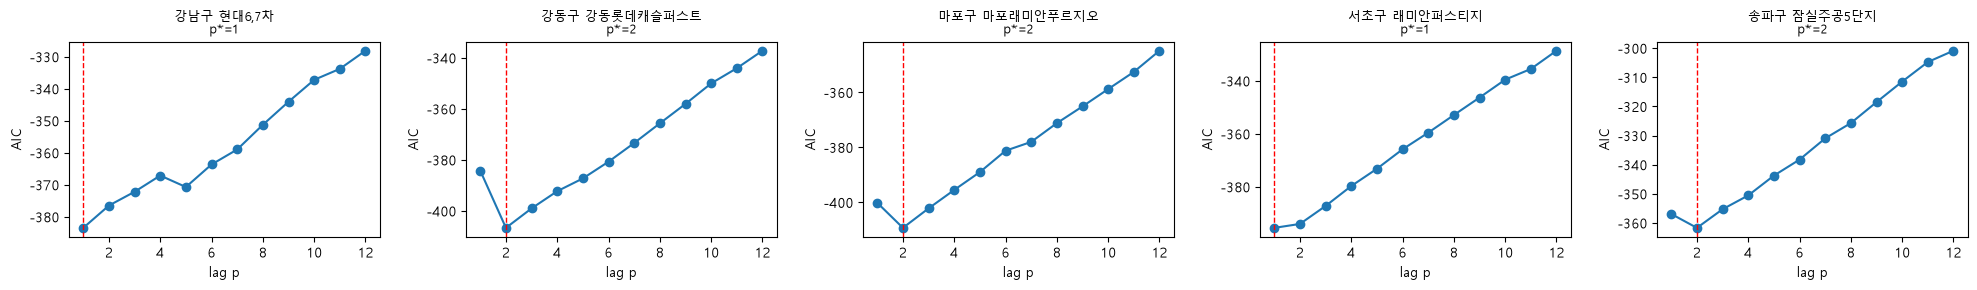

[phase1] 베이스라인 5종: ['RandomWalk', 'SeasonalNaive', 'AR', 'BAR', 'BAR-X']
[phase1] 단지별 AR 차수: {'강남구': 1, '강동구': 2, '마포구': 2, '서초구': 1, '송파구': 2}


In [117]:
from statsmodels.tsa.ar_model import AutoReg

# ---- 베이스라인 모델들 (모두 단지별 시계열에 적합, 모델공간=로그) ----

def fit_select_ar(train_z: np.ndarray, max_lag: int, ic: str) -> int:
    """AIC/BIC로 AR 차수 p 선택. train_z는 모델공간(로그) 1D 배열."""
    n = len(train_z)
    usable_max = min(max_lag, n // 3)  # 표본 대비 과대차수 방지(n/3 가이드)
    best_p, best_ic = 1, np.inf
    scores = {}
    for p in range(1, max(2, usable_max + 1)):
        try:
            res = AutoReg(train_z, lags=p, old_names=False).fit()
            val = res.aic if ic == "aic" else res.bic
            scores[p] = val
            if val < best_ic:
                best_ic, best_p = val, p
        except Exception:
            continue
    return best_p, scores


def forecast_ar(train_z: np.ndarray, p: int, horizon: int) -> np.ndarray:
    """AR(p) 적합 후 horizon 스텝 예측 (모델공간 반환)."""
    res = AutoReg(train_z, lags=p, old_names=False).fit()
    fc = res.predict(start=len(train_z), end=len(train_z) + horizon - 1)
    return np.asarray(fc, float)


def forecast_random_walk(train_z: np.ndarray, horizon: int) -> np.ndarray:
    """마지막 값 유지."""
    return np.repeat(train_z[-1], horizon)


def forecast_seasonal_naive(train_z: np.ndarray, horizon: int, m: int) -> np.ndarray:
    """h 시점 = m개월 전 값. 학습 끝에서 주기적으로 끌어온다."""
    out = np.empty(horizon)
    for h in range(horizon):
        idx = len(train_z) - m + (h % m)
        out[h] = train_z[idx] if idx >= 0 else train_z[-1]
    return out


# ---- BAR / BAR-X : Bayesian AR(-X) + Minnesota prior (Theil mixed) ----
# (단변량 1개 내생 + 외생 동결 → BVAR(벡터) 아님. 명칭 BAR-X)
EXOG_COLS = ["depth1__ecos__base_rate", "depth1__ecos__cd_91d_rate", "depth1__ecos__cpi_housing",
             "depth1__ecos__m2_avg", "depth1__ecos__mortgage_rate_new", "depth1__ecos__unemployment_rate"]


def get_exog_array(df: pd.DataFrame) -> np.ndarray:
    """단지 DataFrame → 시간 오름차순 외생(거시 6개) 배열. 결측 보간."""
    return (df.sort_values(CFG.TIME_COL)[EXOG_COLS]
            .apply(pd.to_numeric, errors="coerce").ffill().bfill().fillna(0.0).values)


def _barx_design(z: np.ndarray, Xex: np.ndarray, p: int):
    """y=z[p:], 설계행렬=[const, z_{t-1..t-p}, 외생_t]. 외생은 동시점(동결 대상)."""
    n = len(z); rows = n - p; cols = 1 + p + Xex.shape[1]
    X = np.empty((rows, cols)); X[:, 0] = 1.0
    for i in range(1, p + 1):
        X[:, i] = z[p - i: n - i]
    X[:, 1 + p:] = Xex[p:]
    return X, z[p:]


def fit_barx_minnesota(z: np.ndarray, Xex: np.ndarray, p: int, lam: float, theta: float):
    """사후평균(일반화 능형). prior: phi1=1, 나머지 0; Var(phi_i)=(lam/i)^2,
    Var(beta_j)=(lam*theta)^2*sigma^2/sigma_xj^2, const 확산. Xex 열0이면 BAR(외생없음)."""
    X, y = _barx_design(z, Xex, p)
    k = X.shape[1]
    beta_ols, *_ = np.linalg.lstsq(X, y, rcond=None)
    sigma2 = float(np.mean((y - X @ beta_ols) ** 2)) or 1e-6
    m = np.zeros(k); m[1] = 1.0                       # phi_1 = 1 (RW)
    V = np.empty(k); V[0] = 1e6 * sigma2              # const 확산
    for i in range(1, p + 1):
        V[i] = (lam / i) ** 2                         # 자기시차 수축
    if Xex.shape[1] > 0:
        sx = Xex[p:].std(axis=0); sx[sx == 0] = 1.0
        V[1 + p:] = (lam * theta) ** 2 * sigma2 / (sx ** 2)   # 외생 교차수축
    Dinv = np.diag(1.0 / V)
    A = X.T @ X + sigma2 * Dinv
    b = X.T @ y + sigma2 * (Dinv @ m)
    beta = np.linalg.solve(A, b)
    return beta, float(sigma2), y - X @ beta


def forecast_barx(beta: np.ndarray, z_hist: np.ndarray, x_frozen: np.ndarray, p: int, H: int) -> np.ndarray:
    """외생 동결(x_frozen) 가정 하 재귀 다단계 예측(로그). x_frozen 빈배열이면 BAR."""
    c = beta[0]; phi = beta[1:1 + p]; bx = beta[1 + p:]
    hist = list(z_hist[-p:])
    exog_term = float(bx @ x_frozen) if len(bx) else 0.0
    out = []
    for _ in range(H):
        zf = c + exog_term + sum(phi[i] * hist[-1 - i] for i in range(p))
        out.append(zf); hist.append(zf)
    return np.asarray(out, float)


# ---- 통합 베이스라인 디스패처 (모든 단계 공유) ----
BASELINE_MODELS = ["RandomWalk", "SeasonalNaive", "AR", "BAR", "BAR-X"]


def _guard_clip(fc: np.ndarray, last: float) -> np.ndarray:
    """폭발근 발산 방지: 학습 마지막 로그값에서 ±AR_FORECAST_GUARD 로 클립."""
    g = CFG.AR_FORECAST_GUARD
    return np.clip(np.asarray(fc, float), last - g, last + g)


def base_forecast_log(name: str, z_tr: np.ndarray, horizon: int,
                      exog_tr: Optional[np.ndarray] = None, p_ar: Optional[int] = None) -> np.ndarray:
    """단일 베이스라인의 horizon-스텝 로그 점예측 (가드 클립 적용)."""
    last = z_tr[-1]
    if name == "RandomWalk":
        return np.repeat(last, horizon)
    if name == "SeasonalNaive":
        return forecast_seasonal_naive(z_tr, horizon, CFG.SEASONAL_PERIOD)
    if name == "AR":
        p = min(p_ar if p_ar else 1, max(1, len(z_tr) // 3))
        try:
            return _guard_clip(forecast_ar(z_tr, p, horizon), last)
        except Exception:
            return np.repeat(last, horizon)
    if name in ("BAR", "BAR-X"):
        p = min(CFG.BARX_MAX_LAG, max(1, len(z_tr) // 3))
        if name == "BAR":
            Xex = np.zeros((len(z_tr), 0)); xf = np.zeros(0)
        else:
            Xex = exog_tr; xf = exog_tr[-1]
        try:
            beta, _, _ = fit_barx_minnesota(z_tr, Xex, p, CFG.MINNESOTA_LAMBDA, CFG.MINNESOTA_THETA)
            return _guard_clip(forecast_barx(beta, z_tr, xf, p, horizon), last)
        except Exception:
            return np.repeat(last, horizon)
    raise ValueError(f"unknown baseline: {name}")


# --- 단지별 AR 차수 선택 + 시각화 ---
ar_orders = {}
fig, axes = plt.subplots(1, len(series_store), figsize=(4 * len(series_store), 3), squeeze=False)
for ax, (key, st) in zip(axes[0], series_store.items()):
    s = get_target_series(st["train"])
    z = to_model_space(s.values)
    p_star, scores = fit_select_ar(z, CFG.AR_MAX_LAG, CFG.AR_IC)
    ar_orders[key] = p_star
    if scores:
        ax.plot(list(scores.keys()), list(scores.values()), "o-")
        ax.axvline(p_star, color="red", ls="--", lw=1)
    ax.set_title(f"{st['gu']} {st['name']}\np*={p_star}", fontsize=9)
    ax.set_xlabel("lag p"); ax.set_ylabel(CFG.AR_IC.upper())
plt.tight_layout(); plt.show()
print("[phase1] 베이스라인 5종:", BASELINE_MODELS)
print("[phase1] 단지별 AR 차수:", {k.split('|')[0]: v for k, v in ar_orders.items()})

## Phase 1-C. 롤링 윈도우 백테스트 — 대표 5단지 (Phase 1-D와 동일 방식, 빠른 점검)

Phase 1-D 와 **완전히 동일한 3개 롤링 윈도우**(8년 train → 24개월 backtest)를 **대표 5단지**에만 적용한
빠른 점검이다. TSCV(확장창) 대신 **단일 원점 24개월 예측**으로 1-D 와 채점 방식을 일치시켜,
대표단지 결과와 KB50 전체 결과를 같은 잣대로 비교할 수 있게 한다.

| 윈도우 | train (8년) | backtest (2년·24개월) |
|---|---|---|
| **W1** | 2016-06 ~ 2024-05 | 2024-06 ~ 2026-05 |
| **W2** | 2015-06 ~ 2023-05 | 2023-06 ~ 2025-05 |
| **W3** | 2014-06 ~ 2022-05 | 2022-06 ~ 2024-05 |

- 대표 5단지의 **컷오프 없는 전체 시계열**(`st["full"]`)을 써서 윈도우 backtest 가 cutoff 너머까지 채점되게 한다.
- 윈도우×단지별 승자(WAPE 최소)를 세어 참고용 챔피언을 표시한다. **최종 B\* 선정은 Phase 1-D(KB50)** 가 담당한다.
- BAR-X 는 거시 외생을 동결해 예측하며, 5종 모두 동일한 윈도우 무대에서 겨룬다.


[phase1-C] 백테스트 윈도우 (8년 train → 24개월 backtest):
  W1: 2016-06~2024-05 → 2024-06~2026-05
  W2: 2015-06~2023-05 → 2023-06~2025-05
  W3: 2014-06~2022-05 → 2022-06~2024-05

=== 대표 5단지 × 3윈도우 베이스라인 5종 평균 RMSE·WAPE ===
                     RMSE   WAPE
모델                              
RandomWalk    60,326.4484 0.1473
SeasonalNaive 62,963.4142 0.1528
AR            67,273.4710 0.1745
BAR           68,335.8485 0.1759
BAR-X         77,873.4229 0.1980

=== 단지×윈도우 우위 카운트 (낮을수록 정확, 총 15 조합) ===
  RandomWalk      WAPE우위  2/15   RMSE우위  2/15
  SeasonalNaive   WAPE우위  2/15   RMSE우위  2/15
  AR              WAPE우위  7/15   RMSE우위  7/15
  BAR             WAPE우위  3/15   RMSE우위  3/15
  BAR-X           WAPE우위  1/15   RMSE우위  1/15

[phase1] 대표단지 베이스라인 챔피언(참고): AR  (최종 B*는 Phase 1-D)

[단지별 WAPE (3윈도우 평균)]


모델,RandomWalk,SeasonalNaive,AR,BAR,BAR-X
단지,,,,,
"강남구 현대6,7차",0.1517,0.1701,0.1675,0.1746,0.2037
강동구 강동롯데캐슬퍼스트,0.1421,0.1568,0.1648,0.1674,0.1746
마포구 마포래미안푸르지오,0.1258,0.1224,0.1387,0.1370,0.1656
서초구 래미안퍼스티지,0.1402,0.1396,0.1677,0.1725,0.2169
송파구 잠실주공5단지,0.1765,0.1753,0.2336,0.2280,0.2292


[단지별 RMSE (3윈도우 평균)]


모델,RandomWalk,SeasonalNaive,AR,BAR,BAR-X
단지,,,,,
"강남구 현대6,7차",111245.0,122396.0,116766.0,121399.0,138850.0
강동구 강동롯데캐슬퍼스트,23328.0,25187.0,26182.0,26500.0,28789.0
마포구 마포래미안푸르지오,29583.0,29160.0,31406.0,31016.0,37566.0
서초구 래미안퍼스티지,68857.0,69078.0,77001.0,79512.0,99353.0
송파구 잠실주공5단지,68620.0,68996.0,85012.0,83252.0,84809.0


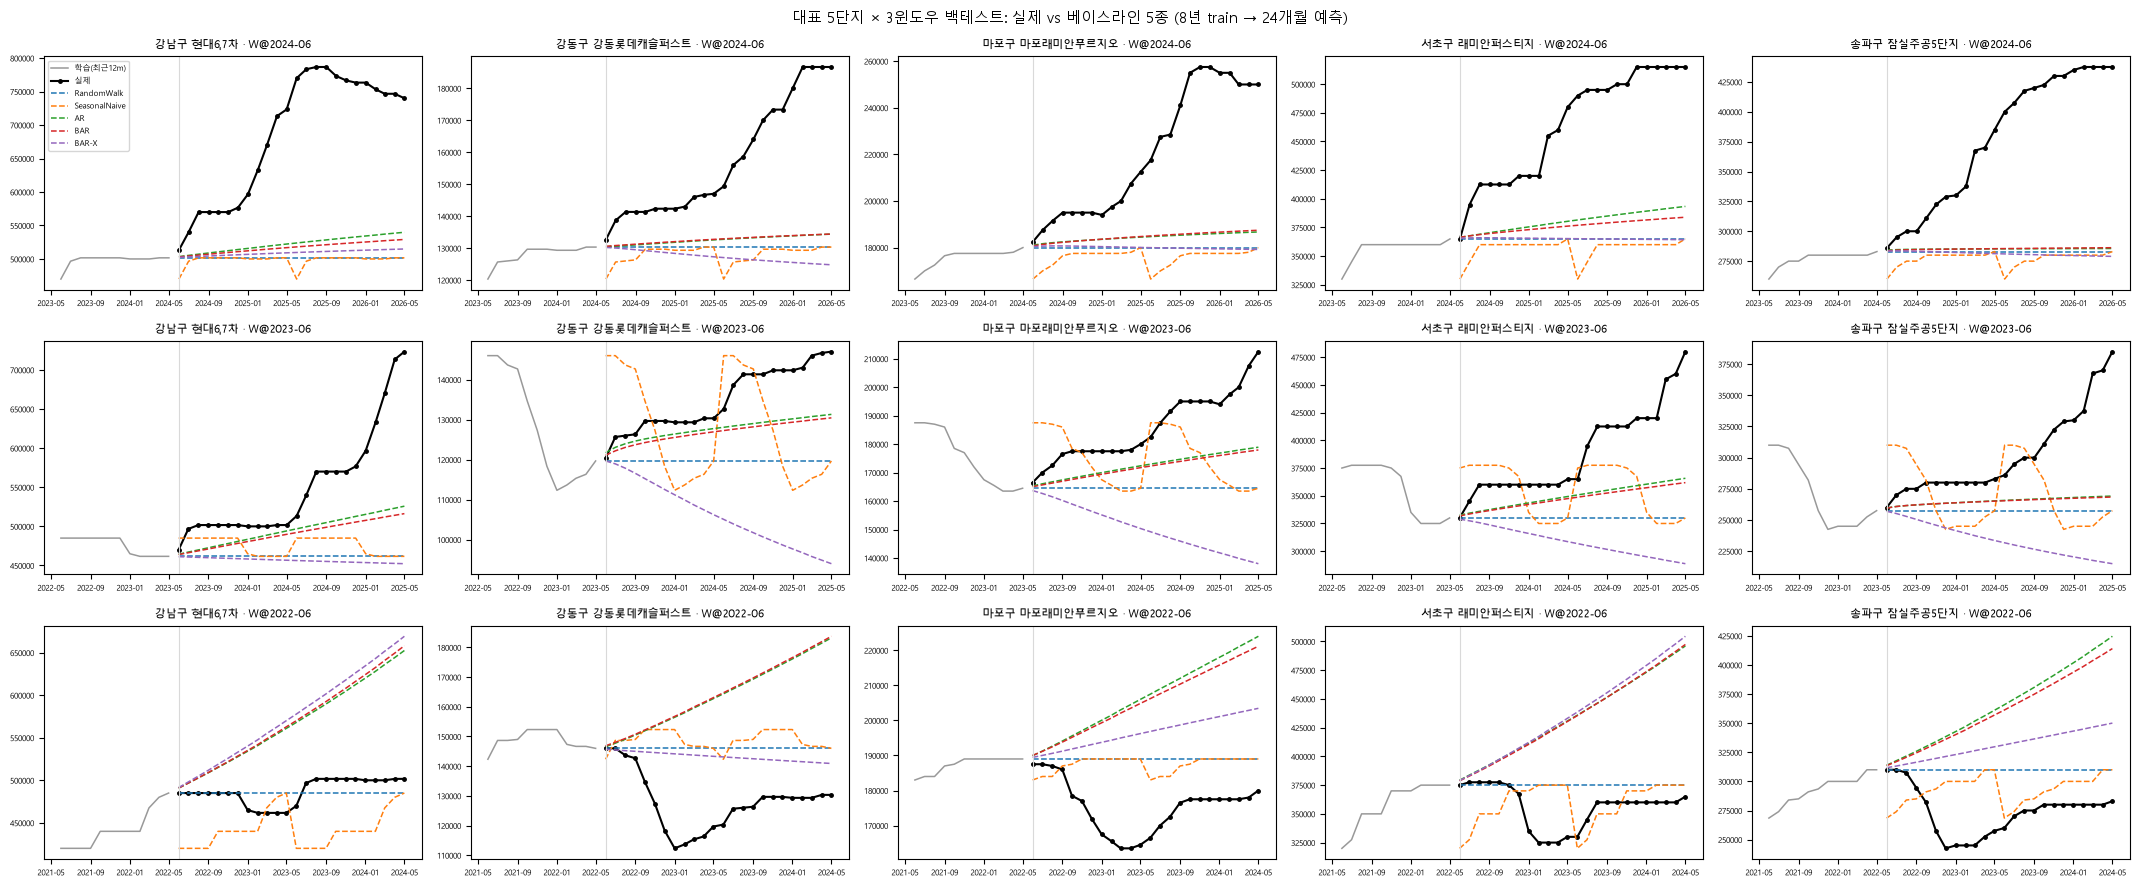

In [118]:
# ===== 대표 5단지 × 3개 롤링 윈도우 백테스트 (Phase 1-D와 동일 방식) =====
# 윈도우 정의 (Phase 1-D와 동일). 셀 단독 실행 가능하도록 여기서도 정의.
def _mk_window(bt_start: str, train_years: int = 8, bt_months: int = 24) -> dict:
    bs = pd.Timestamp(bt_start)
    return {
        "name": f"W@{bs:%Y-%m}",
        "tr_start": bs - pd.DateOffset(years=train_years),
        "tr_end":   bs - pd.DateOffset(months=1),
        "bt_start": bs,
        "bt_end":   bs + pd.DateOffset(months=bt_months - 1),
    }

BT_WINDOWS = [_mk_window("2024-06-01"), _mk_window("2023-06-01"), _mk_window("2022-06-01")]
for _w in BT_WINDOWS:
    _w["label"] = f"{_w['tr_start']:%Y-%m}~{_w['tr_end']:%Y-%m} → {_w['bt_start']:%Y-%m}~{_w['bt_end']:%Y-%m}"


def evaluate_rep_windows() -> pd.DataFrame:
    """대표 5단지 full 시계열 × 3윈도우. 각 윈도우: 8년 train 적합 → 24개월 단일원점 예측 → RMSE/WAPE.
    Drop: train<36개월 또는 backtest<24개월."""
    rows = []
    BT = CFG.HORIZON  # 24
    for key, st in series_store.items():
        g = st["full"].sort_values(CFG.TIME_COL)
        t = g[CFG.TIME_COL]
        label = f"{st['gu']} {st['name']}"
        for w in BT_WINDOWS:
            tr = g[(t >= w["tr_start"]) & (t <= w["tr_end"])]
            bt = g[(t >= w["bt_start"]) & (t <= w["bt_end"])]
            ytr = tr[CFG.TARGET_COL].astype(float).values
            ybt = bt[CFG.TARGET_COL].astype(float).values
            if len(tr) < CFG.MIN_TRAIN_MONTHS or len(bt) < BT:
                continue
            if np.any(ytr <= 0) or np.any(ybt <= 0):
                continue
            z_tr = np.log(ytr) if CFG.LOG_TARGET else ytr
            exog_tr = get_exog_array(tr)
            y_true = ybt[:BT]
            try:
                p_star = fit_select_ar(z_tr, CFG.AR_MAX_LAG, CFG.AR_IC)[0]
            except Exception:
                p_star = 1
            for m in BASELINE_MODELS:
                try:
                    zp = base_forecast_log(m, z_tr, BT, exog_tr=exog_tr, p_ar=p_star)
                except Exception:
                    continue
                yp = to_price_space(zp)
                rows.append({"윈도우": w["name"], "단지": label, "모델": m,
                             "RMSE": rmse(y_true, yp), "WAPE": wape(y_true, yp)})
    return pd.DataFrame(rows)


def win_counts_keyed(df_long: pd.DataFrame, metric: str, keys: List[str]) -> dict:
    """keys 조합별로 metric 최소 모델을 승자 집계 → {모델: 승수}."""
    wins = {}
    for _, gg in df_long.groupby(keys):
        w = gg.loc[gg[metric].idxmin(), "모델"]
        wins[w] = wins.get(w, 0) + 1
    return wins


rep_df = evaluate_rep_windows()
rep_summary = (rep_df.replace([np.inf, -np.inf], np.nan)
               .groupby("모델")[["RMSE", "WAPE"]].mean().reindex(BASELINE_MODELS))
n_cases_rep = rep_df.groupby(["윈도우", "단지"]).ngroups
wins_wape = win_counts_keyed(rep_df, "WAPE", ["윈도우", "단지"])
wins_rmse = win_counts_keyed(rep_df, "RMSE", ["윈도우", "단지"])

print("[phase1-C] 백테스트 윈도우 (8년 train → 24개월 backtest):")
for i, _w in enumerate(BT_WINDOWS, 1):
    print(f"  W{i}: {_w['label']}")

print(f"\n=== 대표 5단지 × 3윈도우 베이스라인 5종 평균 RMSE·WAPE ===")
print(rep_summary.round(4).to_string(float_format=lambda x: f"{x:,.4f}"))
print(f"\n=== 단지×윈도우 우위 카운트 (낮을수록 정확, 총 {n_cases_rep} 조합) ===")
for m in BASELINE_MODELS:
    print(f"  {m:14s}  WAPE우위 {wins_wape.get(m, 0):>2d}/{n_cases_rep}   RMSE우위 {wins_rmse.get(m, 0):>2d}/{n_cases_rep}")
# 대표단지 챔피언(참고용) = WAPE 단지×윈도우 우위 최다 (동률이면 평균 WAPE 낮은 쪽)
BASELINE_CHAMPION = max(BASELINE_MODELS,
                        key=lambda m: (wins_wape.get(m, 0), -rep_summary.loc[m, "WAPE"]))
print(f"\n[phase1] 대표단지 베이스라인 챔피언(참고): {BASELINE_CHAMPION}  (최종 B*는 Phase 1-D)")

# 산출물 저장 + 단지별 표(윈도우 평균)
os.makedirs(os.path.join(CFG.OUT_ROOT, "module1"), exist_ok=True)
rep_df.to_csv(os.path.join(CFG.OUT_ROOT, "module1", "rep_windows_baselines.csv"),
              index=False, encoding="utf-8-sig")
print("\n[단지별 WAPE (3윈도우 평균)]")
display(rep_df.groupby(["단지", "모델"])["WAPE"].mean().unstack("모델")
        .reindex(columns=BASELINE_MODELS).round(4))
print("[단지별 RMSE (3윈도우 평균)]")
display(rep_df.groupby(["단지", "모델"])["RMSE"].mean().unstack("모델")
        .reindex(columns=BASELINE_MODELS).round(0))

# === 시계열 차트(필수): 3윈도우 × 대표단지 — 실제 vs 5개 베이스라인 예측 ===
nC = len(series_store)
fig, axes = plt.subplots(len(BT_WINDOWS), nC, figsize=(4.3 * nC, 3.0 * len(BT_WINDOWS)), squeeze=False)
for ri, w in enumerate(BT_WINDOWS):
    for ci, (key, st) in enumerate(series_store.items()):
        ax = axes[ri][ci]
        g = st["full"].sort_values(CFG.TIME_COL); t = g[CFG.TIME_COL]
        tr = g[(t >= w["tr_start"]) & (t <= w["tr_end"])]
        bt = g[(t >= w["bt_start"]) & (t <= w["bt_end"])]
        if len(tr) < CFG.MIN_TRAIN_MONTHS or len(bt) < CFG.HORIZON:
            ax.set_title(f"{st['gu']} {st['name']} · {w['name']}\n(데이터부족)", fontsize=8)
            ax.axis("off"); continue
        ytr = tr[CFG.TARGET_COL].astype(float).values
        ybt = bt[CFG.TARGET_COL].astype(float).values[:CFG.HORIZON]
        z_tr = np.log(ytr) if CFG.LOG_TARGET else ytr
        exog_tr = get_exog_array(tr)
        p_star = fit_select_ar(z_tr, CFG.AR_MAX_LAG, CFG.AR_IC)[0]
        dtr = tr[CFG.TIME_COL].values; dbt = bt[CFG.TIME_COL].values[:CFG.HORIZON]
        ax.plot(dtr[-12:], ytr[-12:], color="0.6", lw=1.1, label="학습(최근12m)")
        ax.plot(dbt, ybt, color="black", marker="o", ms=2.5, lw=1.5, label="실제")
        for mname in BASELINE_MODELS:
            zp = base_forecast_log(mname, z_tr, CFG.HORIZON, exog_tr=exog_tr, p_ar=p_star)
            ax.plot(dbt, to_price_space(zp), lw=1.1, ls="--", label=mname)
        ax.axvline(dbt[0], color="0.85", lw=0.8)
        ax.set_title(f"{st['gu']} {st['name']} · {w['name']}", fontsize=8)
        ax.tick_params(labelsize=6)
axes[0][0].legend(fontsize=6, loc="best")
plt.suptitle("대표 5단지 × 3윈도우 백테스트: 실제 vs 베이스라인 5종 (8년 train → 24개월 예측)", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUT_ROOT, "module1", "baseline_rep_windows_curves.png"), dpi=110, bbox_inches="tight")
plt.show()

## Phase 1-D. KB 선도 50 아파트 × 3개 롤링 윈도우 백테스트 → **B\* 선정**

위 비교는 **대표 5개 단지**의 빠른 점검이다. **최종 B\* 선정**은 **KB 선도 50 아파트**(서울 대표 거래활발 단지)
를 대상으로 **8년 train → 2년(24개월) backtest** 를 **서로 다른 3개 기간**에 걸쳐 수행하고,
**3윈도우 단지우위 카운트 총합이 가장 많은 모델**을 단일 B\* 로 채택한다(모든 단지 공통 적용).

> **⚠️ 왜 전체 단지가 아니라 KB 선도 50인가?** 전체 패널에는 **거래가 거의 없어 가격이 장기간 평탄한**
> 비유동 단지가 다수 섞여 있다. 이런 단지는 "전월=이번달" 가정이 자동으로 맞아떨어져 **RandomWalk 가 인위적으로 우위**로
> 집계된다. 실제 의사결정 대상인 **거래활발 단지**에서 어떤 베이스라인이 우수한지를 보려면 **KB 선도 50** 으로 한정해야 한다.

| 윈도우 | train (8년) | backtest (2년·24개월) |
|---|---|---|
| **W1** | 2016-06 ~ 2024-05 | 2024-06 ~ 2026-05 |
| **W2** | 2015-06 ~ 2023-05 | 2023-06 ~ 2025-05 |
| **W3** | 2014-06 ~ 2022-05 | 2022-06 ~ 2024-05 |

- **대상** : KB 선도 50 중 **패널에 데이터가 존재하는 단지만** 사용(없는 단지는 자동 제외). 각 단지의 **모든 평형** 포함.
- **데이터 소스** : B\* 선정에는 **컷오프 없는 전체 패널**(2010~2026-05)을 쓴다. 메인 파이프라인(Phase 2~)은
  누수 차단을 위해 기존 `TRAIN_END=2022-08` 컷오프 패널을 그대로 유지한다(여기는 모델 '계열' 선택일 뿐).
- **윈도우 내 예측** : 각 윈도우에서 8년 train 에 적합 → **단일 원점 24개월** 예측 → RMSE·WAPE 채점(1회).
- **Drop 기준** : 각 윈도우에서 train **≥36개월** 이고 backtest **24개월 전부** 존재해야 포함(구간 데이터 부족 시 drop).
- **집계** : 윈도우×단지(평형)별로 승자(WAPE 최소)를 세어 **3윈도우 총합 우위카운트** 최다 모델 = **B\***.
- 결과는 `module1/baseline_windows_kb50.csv` 로 캐시한다.


[phase1-D] KB 선도 50 중 패널 보유 36개 / 누락 14개
  누락(데이터 없음): 강남구 압구정동 현대(1,2차), 서초구 잠원동 신반포(한신2차), 양천구 신정동 목동신시가지(14단지), 양천구 목동 목동신시가지(7단지), 서초구 잠원동 신반포(한신4차), 용산구 서빙고동 신동아, 강남구 도곡동 타워팰리스(1차), 양천구 신정동 목동신시가지(13단지), 용산구 이촌동 한가람, 양천구 목동 목동신시가지(5단지), 양천구 신정동 목동신시가지(9단지), 중구 신당동 남산타운, 양천구 신정동 목동신시가지(10단지), 양천구 목동 목동신시가지(1단지)
[phase1-D] 백테스트 윈도우 (8년 train → 24개월 backtest):
  W1: 2016-06~2024-05 → 2024-06~2026-05
  W2: 2015-06~2023-05 → 2023-06~2025-05
  W3: 2014-06~2022-05 → 2022-06~2024-05
[phase1-D] 캐시 로드: 5,000행

=== 윈도우별 WAPE 우위 카운트 ===
  W@2024-06 (n=346): RandomWalk=12  SeasonalNaive=1  AR=222  BAR=101  BAR-X=10
  W@2023-06 (n=334): RandomWalk=35  SeasonalNaive=12  AR=200  BAR=76  BAR-X=11
  W@2022-06 (n=320): RandomWalk=155  SeasonalNaive=106  AR=0  BAR=19  BAR-X=40

=== 3윈도우 총합 우위 카운트 (총 1,000 평형×윈도우 조합) ===
  RandomWalk      WAPE우위    202 (20.2%)   RMSE우위    190 (19.0%)
  SeasonalNaive   WAPE우위    119 (11.9%)   RMSE우위    123 (12.3%)
  AR              WAPE우위    422 (42.2%)   RMSE우위    437

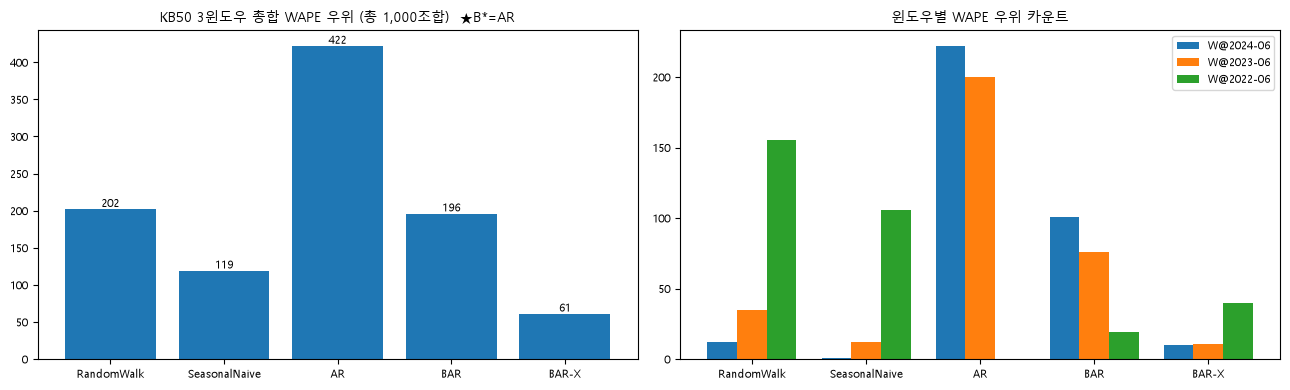

In [119]:
# ===== KB 선도 50 아파트 × 3개 롤링 윈도우 백테스트 (8년 train → 2년 backtest) =====
# (구, 동, KB명, 패널_Header_단지명)  — 패널명 None = 패널에 데이터 없음(자동 제외)
KB_LEADING_50 = [
    ("송파구", "가락동", "헬리오시티", "헬리오시티"),
    ("강남구", "개포동", "디에이치퍼스티어아이파크", "디에이치퍼스티어아이파크"),
    ("송파구", "신천동", "파크리오", "파크리오"),
    ("송파구", "잠실동", "잠실엘스", "잠실엘스"),
    ("송파구", "방이동", "올림픽선수기자촌", "올림픽선수기자촌"),
    ("송파구", "잠실동", "리센츠", "리센츠"),
    ("서초구", "반포동", "래미안원베일리", "래미안원베일리"),
    ("서초구", "반포동", "반포자이", "반포자이"),
    ("송파구", "잠실동", "잠실주공(5단지)", "잠실주공5단지"),
    ("강남구", "대치동", "은마", "은마"),
    ("강남구", "압구정동", "현대(신현대)", "신현대(현대9,11,12차)"),
    ("서초구", "반포동", "래미안퍼스티지", "래미안퍼스티지"),
    ("송파구", "문정동", "올림픽훼밀리타운", "올림픽훼밀리타운"),
    ("강남구", "대치동", "한보미도맨션", "한보미도맨션1,2차"),
    ("송파구", "잠실동", "트리지움", "트리지움"),
    ("강남구", "도곡동", "도곡렉슬", "도곡렉슬"),
    ("강남구", "개포동", "개포자이프레지던스", "개포자이프레지던스"),
    ("강남구", "압구정동", "현대(6,7차)", "현대6,7차"),
    ("강동구", "고덕동", "고덕그라시움", "고덕그라시움"),
    ("서초구", "서초동", "삼풍", "삼풍"),
    ("송파구", "잠실동", "레이크팰리스", "레이크팰리스"),
    ("서초구", "반포동", "아크로리버파크", "아크로리버파크"),
    ("강동구", "상일동", "고덕아르테온", "고덕아르테온"),
    ("강남구", "압구정동", "현대(1,2차)", None),
    ("서초구", "잠원동", "신반포(한신2차)", None),
    ("마포구", "아현동", "마포래미안푸르지오", "마포래미안푸르지오"),
    ("양천구", "신정동", "목동신시가지(14단지)", None),
    ("송파구", "신천동", "장미(1차)", "장미1차"),
    ("강동구", "고덕동", "래미안힐스테이트고덕", "고덕래미안힐스테이트"),
    ("송파구", "잠실동", "아시아선수촌", "아시아선수촌"),
    ("양천구", "목동", "목동신시가지(7단지)", None),
    ("강남구", "개포동", "개포래미안포레스트", "개포래미안포레스트"),
    ("강남구", "일원동", "디에이치자이개포", "디에이치자이개포"),
    ("서초구", "잠원동", "신반포(한신4차)", None),
    ("용산구", "서빙고동", "신동아", None),
    ("송파구", "잠실동", "우성1,2,3차", "우성1,2,3차"),
    ("강남구", "도곡동", "타워팰리스(1차)", None),
    ("강남구", "개포동", "래미안블레스티지", "래미안블레스티지"),
    ("강동구", "암사동", "강동롯데캐슬퍼스트", "강동롯데캐슬퍼스트"),
    ("강남구", "대치동", "래미안대치팰리스1단지", "래미안대치팰리스"),
    ("양천구", "신정동", "목동신시가지(13단지)", None),
    ("용산구", "이촌동", "한가람", None),
    ("양천구", "목동", "목동신시가지(5단지)", None),
    ("서대문구", "남가좌동", "DMC파크뷰자이", "DMC파크뷰자이"),
    ("양천구", "신정동", "목동신시가지(9단지)", None),
    ("마포구", "성산동", "성산시영", "성산시영"),
    ("중구", "신당동", "남산타운", None),
    ("양천구", "신정동", "목동신시가지(10단지)", None),
    ("강남구", "대치동", "선경(1,2차)", "선경1,2차"),
    ("양천구", "목동", "목동신시가지(1단지)", None),
]
KB50_AVAILABLE = [(g, d, p) for g, d, _, p in KB_LEADING_50 if p is not None]
KB50_MISSING = [(g, d, kb) for g, d, kb, p in KB_LEADING_50 if p is None]
KB50_ALLOW = {f"{g}|{d}|{p}" for g, d, p in KB50_AVAILABLE}
print(f"[phase1-D] KB 선도 50 중 패널 보유 {len(KB50_AVAILABLE)}개 / 누락 {len(KB50_MISSING)}개")
if KB50_MISSING:
    print("  누락(데이터 없음): " + ", ".join(f"{g} {d} {kb}" for g, d, kb in KB50_MISSING))


# 백테스트 윈도우: (train_start, train_end, backtest_start, backtest_end) — 모두 월초 기준 포함구간
def _mk_window(bt_start: str, train_years: int = 8, bt_months: int = 24) -> dict:
    bs = pd.Timestamp(bt_start)
    return {
        "name": f"W@{bs:%Y-%m}",
        "tr_start": bs - pd.DateOffset(years=train_years),
        "tr_end":   bs - pd.DateOffset(months=1),
        "bt_start": bs,
        "bt_end":   bs + pd.DateOffset(months=bt_months - 1),
    }

BT_WINDOWS = [_mk_window("2024-06-01"), _mk_window("2023-06-01"), _mk_window("2022-06-01")]
for _w in BT_WINDOWS:
    _w["label"] = f"{_w['tr_start']:%Y-%m}~{_w['tr_end']:%Y-%m} → {_w['bt_start']:%Y-%m}~{_w['bt_end']:%Y-%m}"
print("[phase1-D] 백테스트 윈도우 (8년 train → 24개월 backtest):")
for i, _w in enumerate(BT_WINDOWS, 1):
    print(f"  W{i}: {_w['label']}")


def load_kb50_panel() -> pd.DataFrame:
    """컷오프 없는 전체 패널을 읽되 KB 선도 50(보유분)만 남김 — B* 선정 전용."""
    _need = {"Header_구", "Header_동", "Header_단지명"}
    paths = glob.glob(os.path.join(CFG.PANEL_ROOT, "*", "*", "*.csv"))
    frames = []
    for p in paths:
        try:
            d = pd.read_csv(p, encoding="utf-8-sig")
        except Exception:
            continue
        if len(d) == 0 or CFG.TIME_COL not in d.columns or CFG.TARGET_COL not in d.columns:
            continue
        if not _need.issubset(d.columns):
            continue
        key = f"{d['Header_구'].iloc[0]}|{d['Header_동'].iloc[0]}|{d['Header_단지명'].iloc[0]}"
        if key not in KB50_ALLOW:
            continue
        d[CFG.TIME_COL] = pd.to_datetime(d[CFG.TIME_COL])
        frames.append(d)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def evaluate_baselines_windows(panel: pd.DataFrame) -> Tuple[pd.DataFrame, int, int]:
    """단지×평형 × 3윈도우. 각 윈도우: 8년 train 적합 → 24개월 단일원점 예측 → RMSE/WAPE.
    Drop: train<36개월 또는 backtest<24개월. 반환: (long df[윈도우·단지·모델], 전체그룹수, 사용행수)."""
    _gkeys = ["Header_구", "Header_동", "Header_단지명", "Header_평형"]
    rows = []
    n_groups = n_fit = 0
    BT = CFG.HORIZON  # 24
    for keyvals, g in panel.groupby(_gkeys, sort=False):
        n_groups += 1
        g = g.sort_values(CFG.TIME_COL)
        t = g[CFG.TIME_COL]
        gid = "|".join(str(x) for x in keyvals)
        for w in BT_WINDOWS:
            tr = g[(t >= w["tr_start"]) & (t <= w["tr_end"])]
            bt = g[(t >= w["bt_start"]) & (t <= w["bt_end"])]
            ytr = tr[CFG.TARGET_COL].astype(float).values
            ybt = bt[CFG.TARGET_COL].astype(float).values
            # Drop: 구간 데이터 부족
            if len(tr) < CFG.MIN_TRAIN_MONTHS or len(bt) < BT:
                continue
            if np.any(ytr <= 0) or np.any(ybt <= 0):
                continue
            z_tr = np.log(ytr) if CFG.LOG_TARGET else ytr
            exog_tr = get_exog_array(tr)
            y_true = ybt[:BT]
            try:
                p_star = fit_select_ar(z_tr, CFG.AR_MAX_LAG, CFG.AR_IC)[0]
            except Exception:
                p_star = 1
            for m in BASELINE_MODELS:
                try:
                    zp = base_forecast_log(m, z_tr, BT, exog_tr=exog_tr, p_ar=p_star)
                except Exception:
                    continue
                yp = to_price_space(zp)
                rows.append({"윈도우": w["name"], "단지": gid, "모델": m,
                             "RMSE": rmse(y_true, yp), "WAPE": wape(y_true, yp)})
            n_fit += 1
    return pd.DataFrame(rows), n_groups, n_fit


_win_cache = os.path.join(CFG.OUT_ROOT, "module1", "baseline_windows_kb50.csv")
os.makedirs(os.path.join(CFG.OUT_ROOT, "module1"), exist_ok=True)
if os.path.exists(_win_cache):
    win_df = pd.read_csv(_win_cache, encoding="utf-8-sig")
    print(f"[phase1-D] 캐시 로드: {len(win_df):,}행")
else:
    kb50_panel = load_kb50_panel()
    _n_apt = kb50_panel[["Header_구", "Header_동", "Header_단지명"]].drop_duplicates().shape[0]
    print(f"[phase1-D] KB50 패널(컷오프 없음): {kb50_panel.shape[0]:,}행  "
          f"단지 {_n_apt}개  기간 {kb50_panel[CFG.TIME_COL].min().date()}~{kb50_panel[CFG.TIME_COL].max().date()}")
    win_df, _ng, _nf = evaluate_baselines_windows(kb50_panel)
    win_df.to_csv(_win_cache, index=False, encoding="utf-8-sig")
    print(f"[phase1-D] {_ng:,}개 단지·평형 × 3윈도우 → 적합 케이스 {_nf:,}개 (평형·윈도우 조합)")


def win_counts_keyed(df_long: pd.DataFrame, metric: str, keys: List[str]) -> dict:
    """keys 조합별로 metric 최소 모델을 승자 집계 → {모델: 승수}."""
    wins = {}
    for _, gg in df_long.groupby(keys):
        w = gg.loc[gg[metric].idxmin(), "모델"]
        wins[w] = wins.get(w, 0) + 1
    return wins


# 비유한값(폭발근 등) 제외 평균 + 윈도우별/총합 우위 카운트
_finite = win_df.replace([np.inf, -np.inf], np.nan)
all_summary = _finite.groupby("모델")[["RMSE", "WAPE"]].mean().reindex(BASELINE_MODELS)
n_cases = win_df.groupby(["윈도우", "단지"]).ngroups   # 평형×윈도우 조합 총수
# 윈도우×단지(평형)별 승자 → 3윈도우 총합 우위카운트
wins_wape_all = win_counts_keyed(win_df, "WAPE", ["윈도우", "단지"])
wins_rmse_all = win_counts_keyed(win_df, "RMSE", ["윈도우", "단지"])

#print(f"\n=== KB50 × 3윈도우 베이스라인 5종 평균 RMSE·WAPE (비유한값 제외) ===")
#print(all_summary.round(4).to_string(float_format=lambda x: f"{x:,.4f}"))

# 윈도우별 우위 카운트 분해
print(f"\n=== 윈도우별 WAPE 우위 카운트 ===")
_win_breakdown = {}
for w in BT_WINDOWS:
    sub = win_df[win_df["윈도우"] == w["name"]]
    ww = win_counts_keyed(sub, "WAPE", ["단지"])
    _win_breakdown[w["name"]] = ww
    n_w = sub["단지"].nunique()
    print(f"  {w['name']} (n={n_w:,}): " + "  ".join(f"{m}={ww.get(m, 0)}" for m in BASELINE_MODELS))

print(f"\n=== 3윈도우 총합 우위 카운트 (총 {n_cases:,} 평형×윈도우 조합) ===")
for m in BASELINE_MODELS:
    ww, wr = wins_wape_all.get(m, 0), wins_rmse_all.get(m, 0)
    print(f"  {m:14s}  WAPE우위 {ww:>6,} ({ww/n_cases:5.1%})   RMSE우위 {wr:>6,} ({wr/n_cases:5.1%})")

# === 전역 단일 B* 선정: 3윈도우 총합 WAPE 우위카운트 최다 (동률이면 평균 WAPE 낮은 쪽) ===
BASELINE_CHAMPION_ALL = max(BASELINE_MODELS,
                            key=lambda m: (wins_wape_all.get(m, 0), -all_summary.loc[m, "WAPE"]))
B_STAR = BASELINE_CHAMPION_ALL
print(f"\n[phase1-D] ★ 전역 베이스라인 B* (KB50 3윈도우 총합 우위 최다, 모든 단지 공통 적용): {B_STAR}")
print(f"[phase1-D] 대표 5단지 챔피언({BASELINE_CHAMPION}) 과 "
      f"{'일치 → 일반화 타당' if BASELINE_CHAMPION_ALL == BASELINE_CHAMPION else '불일치 → KB50·3윈도우 기준 채택'}")

# 시각화: (좌) 3윈도우 총합 WAPE 우위, (우) 윈도우별 WAPE 우위 그룹막대
fig, axw = plt.subplots(1, 2, figsize=(13, 4))
mods = list(BASELINE_MODELS)
bars0 = axw[0].bar(mods, [wins_wape_all.get(m, 0) for m in mods], color="tab:blue")
axw[0].set_title(f"KB50 3윈도우 총합 WAPE 우위 (총 {n_cases:,}조합)  ★B*={B_STAR}", fontsize=10)
for rect in bars0:
    axw[0].text(rect.get_x() + rect.get_width() / 2, rect.get_height(),
                f"{int(rect.get_height()):,}", ha="center", va="bottom", fontsize=8)
x = np.arange(len(mods)); wlabels = [w["name"] for w in BT_WINDOWS]
for j, wn in enumerate(wlabels):
    axw[1].bar(x + (j - 1) * 0.26, [_win_breakdown[wn].get(m, 0) for m in mods],
               width=0.26, label=wn)
axw[1].set_xticks(x); axw[1].set_xticklabels(mods, fontsize=8)
axw[1].set_title("윈도우별 WAPE 우위 카운트", fontsize=10); axw[1].legend(fontsize=8)
for a in axw:
    a.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUT_ROOT, "module1", "baseline_windows_wincounts.png"), dpi=110, bbox_inches="tight")
plt.show()

# Phase 2. B\* 를 CatBoost 로 부스팅 — 밴드형 예측 (Before vs After)

Phase 1 에서 **전체 단지 우위카운트로 단일 베이스라인 B\*** 를 골랐다(`B_STAR`).
이제 그 **B\* 를 CatBoost 로 잔차보정(boost)** 하고, **마지막에 부트스트랩으로 밴드**를 씌운다.
효과 검증은 **CatBoost 부스팅 전(Before) vs 후(After)** 를 같은 부트스트랩 엔진으로 비교한다.

## 단일 파이프라인 + Before/After 비교

```
B*  (Phase 1-D 선정 베이스라인, 단지별·로컬 점예측)
 │
 ├─[Before]→ + 블록 부트스트랩 ─────────────→ 밴드 P10/P50/P90   (CatBoost 미적용)
 │
 └─[After ]→ + CatBoost 잔차보정 → + 블록 부트스트랩 → 밴드 P10/P50/P90   (CatBoost 적용)
```

**핵심 순서** : B\* 점예측 → (After 만) 잔차보정 → **마지막에 부트스트랩으로 밴드**.
부트스트랩은 Before/After 가 **공유**하는 마지막 엔진이다 → "엔진 하나, 보정만 교체".
혁신 풀만 교체한다 : Before = B\* 의 **원시 h스텝 오차증분**, After = **보정 후 오차증분**.

## 정보 가정 (투명성 명시)

- B\* 의 점예측은 단지별 로컬 시계열로 산출(BAR-X 가 B\*면 거시 외생을 `TRAIN_END` 수준으로 동결).
- **CatBoost 보정(After)** 은 예측구간의 **실현된 거시경로**(depth1/2/3)를 피처로 사용한다(conditional).
  → "거시 시나리오가 주어졌을 때" 보정이 B\* 점예측을 실제값에 얼마나 더 가깝게 만드는지를 본다.

## 누수 차단 재확인

전역 CatBoost 는 `TRAIN_END(2022-08)` 이하 행에만 학습한다(Phase 0의 공통 컷오프 패널).
추론 시 예측구간 거시값을 **피처로만** 넣을 뿐, 그 시점의 가격(타깃)은 학습에 없다.
원점추세 피처(`base_drift`, `origin_*`)는 학습세트와 **동일 정의**로 재현 → 누수 없음.

## Phase 2-A. 전역 잔차 학습세트 구성 — B\* **h스텝 예측오차**

> **설계 변경 근거** : 1스텝 in-sample 잔차는 정의상 백색화되어 거시·정적 피처로 설명되지 않는다(검증 완료).
> 대신 **h스텝 예측오차**를 타깃으로 쓴다. B\* 는 예측 원점에서 미래 거시를 모른 채 외삽하므로,
> "예측 후 실제로 실현된 거시"가 그 오차(드리프트)를 설명할 수 있다 → CatBoost 에 **진짜 신호**가 생긴다.

전체 패널의 각 단지×평형에 대해 **롤링 예측원점** $t_0$ 를 `ORIGIN_STRIDE` 간격으로 잡고,
각 원점에서 **B\*** 로 $h=1\dots H$ 를 예측한 뒤 실현값과의 오차를 모은다.

$$e^{(c)}_{t_0,h} = \log P^{(c)}_{t_0+h} \;-\; \widehat{\log P^{(c)}_{t_0+h}}\Big|_{B^{*}\text{ from } t_0}$$

- **피처(2종)** :
  1. *실현시점* $t_0+h$ 의 거시(D1/D2/D3) + 단지 Static — B\* 가 원점에서 몰랐던 "실현 거시" 신호.
  2. **원점추세** `ORIGIN_FEATS` = $\{\text{base\_drift}_h,\ \text{origin\_last},\ \text{origin\_mom}_{3/6/12}\}$ — 예측시점 기지값.
     - $\text{base\_drift}_h = \widehat{\log P}_{t_0+h} - \log P_{t_0-1}$ : B\* 가 원점→$h$ 로 외삽한 변화량(RW면 0).
     - $\text{origin\_mom}_k = \log P_{t_0-1} - \log P_{t_0-1-k}$ : 원점 직전 $k$ 개월 모멘텀.
- **원점추세를 넣는 이유** : 오차 $e=\log P - \widehat{\log P}$ 의 *방향*은 "B\* 가 무엇을 예측했는가"에 달려 있다.
  실현거시만으론 부족 — 레짐 전환(2021–22 고점·하락) 구간에서 train/valid 의 오차 부호가 뒤집혀
  보정이 무보정보다 나빠질 수 있다. `base_drift` 등 원점추세 추가로 방향을 고정. **누수 없음**(모두 원점 기지값) → 추론에서 동일 재현.
- 여러 원점 → 여러 거시레짐(상승·하락·횡보)을 포함해 편향 완화.
- 한 번 만들고 pickle 캐시(`module2/hstep_trainset_*.pkl`, B\* 별로 분리).

In [120]:
GROUP_KEYS = ["Header_구", "Header_동", "Header_단지명", "Header_평형"]
HSTEP_COL = "h_step"

# Static 중 본래 수치형(역세권수/호재수)은 numeric으로, 나머지 Static은 categorical로
def split_features(columns: List[str]) -> Tuple[List[str], List[str]]:
    num, cat = feature_columns(columns)  # num=D1+D2+D3, cat=Static 전체
    cat_final = [c for c in cat if c not in STATIC_NUMERIC_HINT]
    num_final = num + [c for c in cat if c in STATIC_NUMERIC_HINT]
    return num_final, cat_final


# 원점(예측시점)에 알 수 있는 추세/모멘텀 피처 — h스텝 오차의 '방향'을 알려줌(누수 없음)
ORIGIN_FEATS = ["base_drift", "origin_last", "origin_mom3", "origin_mom6", "origin_mom12"]

_num0, CAT_FEATS = split_features(list(global_panel.columns))
NUM_FEATS = _num0 + ([HSTEP_COL] if CFG.INCLUDE_HSTEP_FEATURE else []) + ORIGIN_FEATS
print(f"[feat] 수치피처 {len(NUM_FEATS)}개(=거시+카운트+h_step+원점추세{len(ORIGIN_FEATS)})  | 범주피처 {len(CAT_FEATS)}개: {CAT_FEATS}")


def build_hstep_trainset(panel: pd.DataFrame, b_star: str) -> pd.DataFrame:
    """패널 각 단지×평형에서 롤링 원점 B*(=b_star) → h스텝 예측오차를 타깃으로.
    오차 행의 피처 = 실현시점(t0+h)의 거시/정적 + h_step + 원점추세."""
    out_frames = []
    n_groups = n_used = n_samples = 0
    H = CFG.HORIZON
    for _, g in panel.groupby(GROUP_KEYS, sort=False):
        n_groups += 1
        g = g.sort_values(CFG.TIME_COL).reset_index(drop=True)
        y = g[CFG.TARGET_COL].astype(float).values
        n = len(g)
        if n < CFG.MIN_TRAIN_MONTHS + 1 or np.any(y <= 0):
            continue
        z = np.log(y) if CFG.LOG_TARGET else y
        Xex_g = get_exog_array(g)                            # 거시 외생(B*=BAR-X일 때 사용)
        # 단지별 AR 차수 p는 1회만 선택(AR 계열일 때만 필요) → 원점마다 재선택 비용 제거
        p_c = fit_select_ar(z, CFG.PANEL_AR_MAX_LAG, CFG.AR_IC)[0] if b_star == "AR" else None
        used_this = False
        # 롤링 원점: 충분한 학습량 확보 후 STRIDE 간격
        for t0 in range(CFG.MIN_TRAIN_MONTHS, n - 1, CFG.ORIGIN_STRIDE):
            z_tr = z[:t0]
            hmax = min(H, n - 1 - t0)
            if hmax < 1:
                continue
            try:
                fc = base_forecast_log(b_star, z_tr, hmax, exog_tr=Xex_g[:t0], p_ar=p_c)  # B* 점예측(로그)
            except Exception:
                continue
            fc = np.asarray(fc, float)
            # --- 안정성 가드: 발산 예측 제외 ---
            if not np.all(np.isfinite(fc)):
                continue
            if np.max(np.abs(fc - z_tr[-1])) > CFG.AR_FORECAST_GUARD:
                continue
            idx_future = np.arange(t0, t0 + hmax)          # 실현 시점 인덱스
            err = z[idx_future] - fc                         # h스텝 로그오차
            drift = fc - z_tr[-1]                            # B*가 원점→h로 외삽한 변화량(RW면 0)
            keep = np.abs(err) <= CFG.ERR_CLIP_LOG          # 경제/수치 이상치 제외
            if not np.any(keep):
                continue
            idx_future, err, drift = idx_future[keep], err[keep], drift[keep]
            rows = g.iloc[idx_future].copy()
            rows[HSTEP_COL] = (idx_future - t0 + 1)          # h = 1..hmax
            rows["resid_target"] = err
            # --- 원점 추세 피처(예측시점 기지값) ---
            last = z_tr[-1]
            rows["base_drift"]  = drift
            rows["origin_last"] = last
            rows["origin_mom3"]  = (last - z_tr[-4])  if len(z_tr) >= 4  else 0.0
            rows["origin_mom6"]  = (last - z_tr[-7])  if len(z_tr) >= 7  else 0.0
            rows["origin_mom12"] = (last - z_tr[-13]) if len(z_tr) >= 13 else 0.0
            out_frames.append(rows)
            n_samples += int(keep.sum())
            used_this = True
        if used_this:
            n_used += 1
    res_df = pd.concat(out_frames, ignore_index=True) if out_frames else pd.DataFrame()
    print(f"[resid] B*={b_star} | 그룹 {n_groups:,}개 중 {n_used:,}개 사용 → h스텝 오차샘플 {len(res_df):,}")
    return res_df


_bstar_tag = B_STAR.replace("-", "").replace("/", "")
_resid_cache = os.path.join(CFG.OUT_ROOT, "module2", f"hstep_trainset_{_bstar_tag}_{CFG.TRAIN_END[:7]}.pkl")
os.makedirs(os.path.join(CFG.OUT_ROOT, "module2"), exist_ok=True)
if os.path.exists(_resid_cache):
    resid_train = pd.read_pickle(_resid_cache)
    print(f"[resid] 캐시 로드: {len(resid_train):,}행 (B*={B_STAR})")
else:
    resid_train = build_hstep_trainset(global_panel, B_STAR)
    resid_train.to_pickle(_resid_cache)

print(f"[resid] h스텝 오차 학습세트(B*={B_STAR}): {resid_train.shape[0]:,}행 × {resid_train.shape[1]}열")
print(f"[resid] 오차 통계  mean={resid_train['resid_target'].mean():.5f}  std={resid_train['resid_target'].std():.5f}")
print(f"[resid] h_step 범위: {int(resid_train[HSTEP_COL].min())}~{int(resid_train[HSTEP_COL].max())}")

[feat] 수치피처 24개(=거시+카운트+h_step+원점추세5)  | 범주피처 5개: ['Static__준공구분', 'Static__세대수구분', 'Static__평수구분', 'Static__건설사등급', 'Static__초품아여부']
[resid] 캐시 로드: 1,066,066행 (B*=AR)
[resid] h스텝 오차 학습세트(B*=AR): 1,066,066행 × 37열
[resid] 오차 통계  mean=-0.00436  std=0.16145
[resid] h_step 범위: 1~24


## Phase 2-B. 전역 CatBoost — 잔차 보정 모델 학습

잔차 $e_t$ 를 **정적 속성(categorical)** 과 **거시(numeric)** 로 회귀한다.

$$\widehat{e}_t = f_{\text{CatBoost}}\big(\underbrace{\text{Static}}_{\text{건설사·평수·세대수·초품아}},\ \underbrace{D1,D2,D3}_{\text{거시·권역·구별}}\big)$$

- **categorical** : `Static__준공/세대수/평수/건설사등급/초품아` → 단지 간 횡단면 차이를 학습.
- **numeric** : `depth1/2/3` 거시 + `Static__역세권수/호재수` (본래 수치).
- 시간 기반 hold-out(마지막 12개월)을 검증셋으로 early stopping → 과적합 방지.
- 손실 = RMSE(잔차는 로그공간이라 대칭).


In [121]:
def _prep_features(df: pd.DataFrame) -> pd.DataFrame:
    """CatBoost 입력 정리: categorical은 문자열+결측'NA', numeric은 float."""
    X = df[NUM_FEATS + CAT_FEATS].copy()
    for c in CAT_FEATS:
        X[c] = X[c].astype("object").where(X[c].notna(), "NA").astype(str)
    for c in NUM_FEATS:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    return X


# 시간 기반 train/valid 분리 (마지막 12개월 = early stopping 검증)
_cut_valid = resid_train[CFG.TIME_COL].max() - pd.DateOffset(months=12)
tr_mask = resid_train[CFG.TIME_COL] <= _cut_valid
X_tr = _prep_features(resid_train[tr_mask])
y_tr = resid_train.loc[tr_mask, "resid_target"].values
X_va = _prep_features(resid_train[~tr_mask])
y_va = resid_train.loc[~tr_mask, "resid_target"].values

cat_idx = [X_tr.columns.get_loc(c) for c in CAT_FEATS]
train_pool = Pool(X_tr, y_tr, cat_features=cat_idx)
valid_pool = Pool(X_va, y_va, cat_features=cat_idx)

cb_model = CatBoostRegressor(
    iterations=CFG.CB_ITERATIONS,
    learning_rate=CFG.CB_LEARNING_RATE,
    depth=CFG.CB_DEPTH,
    l2_leaf_reg=CFG.CB_L2_LEAF_REG,
    loss_function="RMSE",
    random_seed=CFG.CB_RANDOM_SEED,
    task_type=CATBOOST_TASK_TYPE,
    od_type="Iter",
    od_wait=CFG.CB_EARLY_STOP,
    verbose=100,
)
cb_model.fit(train_pool, eval_set=valid_pool, use_best_model=True)
cb_model.save_model(os.path.join(CFG.OUT_ROOT, "module2", "catboost_residual.cbm"))

_pred_va = cb_model.predict(X_va)
print(f"\n[catboost] best_iter={cb_model.get_best_iteration()}  "
      f"valid RMSE(resid)={rmse(y_va, _pred_va):.5f}  (잔차 std={y_va.std():.5f})")


0:	learn: 0.1409632	test: 0.2717961	best: 0.2717961 (0)	total: 274ms	remaining: 3m 39s
100:	learn: 0.0706071	test: 0.1474693	best: 0.1474693 (100)	total: 23.8s	remaining: 2m 44s
200:	learn: 0.0626248	test: 0.1321345	best: 0.1321345 (200)	total: 48.2s	remaining: 2m 23s
300:	learn: 0.0596391	test: 0.1276224	best: 0.1275725 (294)	total: 1m 11s	remaining: 1m 58s
400:	learn: 0.0578600	test: 0.1238363	best: 0.1238363 (400)	total: 1m 34s	remaining: 1m 34s
500:	learn: 0.0565064	test: 0.1205993	best: 0.1205736 (499)	total: 2m	remaining: 1m 12s
600:	learn: 0.0554447	test: 0.1184980	best: 0.1184980 (600)	total: 2m 28s	remaining: 49.1s
700:	learn: 0.0545618	test: 0.1176404	best: 0.1176404 (700)	total: 2m 51s	remaining: 24.2s
799:	learn: 0.0538201	test: 0.1165132	best: 0.1165132 (799)	total: 3m 15s	remaining: 0us

bestTest = 0.1165131562
bestIteration = 799


[catboost] best_iter=799  valid RMSE(resid)=0.11651  (잔차 std=0.18658)


In [122]:
# === Phase 2-B 진단: 무보정 대비 CatBoost 보정 이득 분해 ===
# 핵심 질문: (1) valid가 train과 분포이동? (2) 오차는 h_step(horizon)에 따라 어떻게 커지나?
#           (3) CatBoost가 '0 예측(무보정)'보다 어디서 나쁜가?
def _zero_rmse(y):           # 무보정(보정=0) 기준 RMSE
    return float(np.sqrt(np.mean(np.square(y))))

print("=== train vs valid 분포 ===")
print(f"  train  n={len(y_tr):,}  mean={y_tr.mean():+.4f}  std={y_tr.std():.4f}")
print(f"  valid  n={len(y_va):,}  mean={y_va.mean():+.4f}  std={y_va.std():.4f}")
print(f"  valid 실현기간: {resid_train.loc[~tr_mask, CFG.TIME_COL].min():%Y-%m} ~ "
      f"{resid_train.loc[~tr_mask, CFG.TIME_COL].max():%Y-%m}")

print("\n=== valid: 무보정 vs CatBoost (전체) ===")
print(f"  무보정 RMSE = {_zero_rmse(y_va):.5f}")
print(f"  CatBoost RMSE = {rmse(y_va, _pred_va):.5f}")
print(f"  (이득 = {(_zero_rmse(y_va) - rmse(y_va, _pred_va)):+.5f}, +면 보정이 나음)")

print("\n=== h_step(horizon)별 분해 — valid ===")
_hva = resid_train.loc[~tr_mask, HSTEP_COL].values
_rows = []
for h in range(1, CFG.HORIZON + 1):
    m = _hva == h
    if m.sum() < 30:
        continue
    yz, yp = y_va[m], _pred_va[m]
    _rows.append({
        "h": h, "n": int(m.sum()),
        "bias": float(yz.mean()),
        "무보정RMSE": _zero_rmse(yz),
        "CB RMSE": float(np.sqrt(np.mean((yz - yp) ** 2))),
    })
_diag = pd.DataFrame(_rows)
_diag["이득"] = _diag["무보정RMSE"] - _diag["CB RMSE"]
print(_diag.to_string(index=False, float_format=lambda v: f"{v:+.4f}"))
print(f"\n  보정이 이득인 h 비율: {(_diag['이득'] > 0).mean():.0%}")


=== train vs valid 분포 ===
  train  n=952,132  mean=+0.0174  std=0.1435
  valid  n=113,934  mean=-0.1863  std=0.1866
  valid 실현기간: 2022-06 ~ 2023-05

=== valid: 무보정 vs CatBoost (전체) ===
  무보정 RMSE = 0.26367
  CatBoost RMSE = 0.11651
  (이득 = +0.14715, +면 보정이 나음)

=== h_step(horizon)별 분해 — valid ===
 h    n    bias  무보정RMSE  CB RMSE      이득
 1 5145 -0.0150  +0.0295  +0.0320 -0.0025
 2 5101 -0.0291  +0.0480  +0.0413 +0.0067
 3 5121 -0.0448  +0.0665  +0.0519 +0.0146
 4 5101 -0.0610  +0.0813  +0.0618 +0.0194
 5 1987 -0.0607  +0.0822  +0.0571 +0.0252
 6 5116 -0.0866  +0.1046  +0.0479 +0.0567
 7 5143 -0.1037  +0.1235  +0.0593 +0.0642
 8 5077 -0.1206  +0.1422  +0.0695 +0.0728
 9 5136 -0.1391  +0.1632  +0.0833 +0.0798
10 4906 -0.1644  +0.1919  +0.1011 +0.0908
11 5069 -0.1833  +0.2153  +0.1206 +0.0947
12 5138 -0.2081  +0.2460  +0.1433 +0.1027
13 5088 -0.2380  +0.2798  +0.1558 +0.1240
14 5028 -0.2635  +0.3094  +0.1691 +0.1403
15 5038 -0.2880  +0.3377  +0.1851 +0.1526
16 5002 -0.3081  +0.3612  +0.1

### Phase 2-B 시각화 — CatBoost 잔차보정 효과 (단지별)

B\* 단독 점예측과 CatBoost로 h스텝 오차를 보정·합산한 점예측, 그리고 **실제 시세**를 한 그래프에 겹쳐
**"CatBoost 보정이 실제값에 더 가까워지는가"** 를 단지별로 시각 검증한다. (부트스트랩 이전 — 순수 점예측 비교)

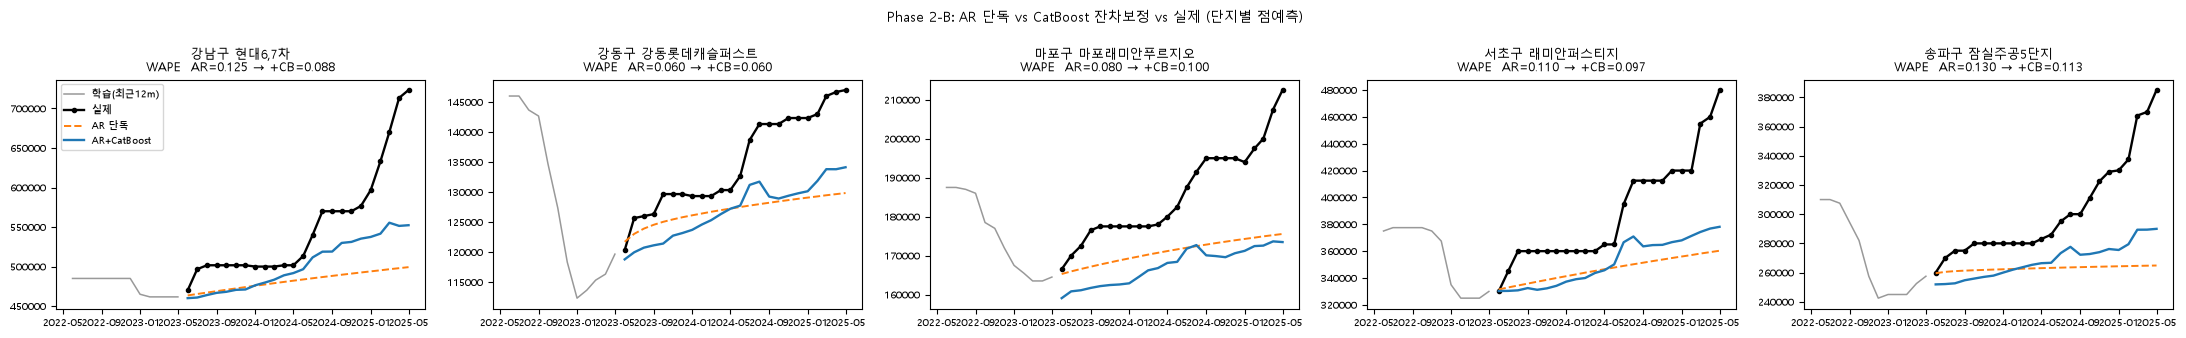

=== 점예측 WAPE: AR 단독 vs AR+CatBoost (개선=양수면 CatBoost가 더 정확) ===
               WAPE_B*  WAPE_B*+CB      개선
단지                                        
강남구 현대6,7차      0.1246      0.0879  0.0367
강동구 강동롯데캐슬퍼스트   0.0604      0.0599  0.0006
마포구 마포래미안푸르지오   0.0798      0.1001 -0.0202
서초구 래미안퍼스티지     0.1099      0.0965  0.0133
송파구 잠실주공5단지     0.1304      0.1131  0.0174

[phase2-B] CatBoost 보정이 더 정확한 단지: 4/5


In [123]:
# === 단지별 Trend: B* 단독 vs B*+CatBoost vs 실제 (부트스트랩 전 점예측) ===
def _base_and_corrected(key: str, st: dict):
    """bstar_forecast의 결정론적 핵심만 추출 — B* 점예측과 CatBoost 보정 점예측."""
    train_df = st["train"]; test_df = st["test"].sort_values(CFG.TIME_COL).reset_index(drop=True)
    s_tr = get_target_series(train_df)
    z_tr = to_model_space(s_tr.values)
    exog_tr = get_exog_array(train_df)
    p_c = ar_orders[key]
    H = min(CFG.HORIZON, len(test_df))
    base_log = base_forecast_log(B_STAR, z_tr, H, exog_tr=exog_tr, p_ar=p_c)
    last = z_tr[-1]
    feat = test_df.iloc[:H].copy()
    feat[HSTEP_COL]      = np.arange(1, H + 1)
    feat["base_drift"]   = base_log - last
    feat["origin_last"]  = last
    feat["origin_mom3"]  = (last - z_tr[-4])  if len(z_tr) >= 4  else 0.0
    feat["origin_mom6"]  = (last - z_tr[-7])  if len(z_tr) >= 7  else 0.0
    feat["origin_mom12"] = (last - z_tr[-13]) if len(z_tr) >= 13 else 0.0
    corr = cb_model.predict(_prep_features(feat))
    point_log = base_log + corr
    actual = test_df[CFG.TARGET_COL].astype(float).values[:H]
    dates  = pd.to_datetime(test_df[CFG.TIME_COL].values[:H])
    return dates, actual, to_price_space(base_log), to_price_space(point_log), s_tr


fig, axes = plt.subplots(1, len(series_store), figsize=(4.4 * len(series_store), 3.4), squeeze=False)
_imp_rows = []
for ax, (key, st) in zip(axes[0], series_store.items()):
    dates, actual, base_price, cb_price, s_tr = _base_and_corrected(key, st)
    ctx = s_tr.iloc[-12:]
    ax.plot(ctx.index, ctx.values, color="0.6", lw=1.1, label="학습(최근12m)")
    ax.plot(dates, actual, color="black", marker="o", ms=3, lw=1.7, label="실제")
    ax.plot(dates, base_price, color="tab:orange", ls="--", lw=1.4, label=f"{B_STAR} 단독")
    ax.plot(dates, cb_price, color="tab:blue", lw=1.7, label=f"{B_STAR}+CatBoost")
    w_base = wape(actual, base_price); w_cb = wape(actual, cb_price)
    _imp_rows.append({"단지": f"{st['gu']} {st['name']}", "WAPE_B*": w_base, "WAPE_B*+CB": w_cb,
                      "개선": w_base - w_cb})
    ax.set_title(f"{st['gu']} {st['name']}\nWAPE  {B_STAR}={w_base:.3f} → +CB={w_cb:.3f}", fontsize=9)
    ax.tick_params(labelsize=7)
axes[0][0].legend(fontsize=7, loc="best")
plt.suptitle(f"Phase 2-B: {B_STAR} 단독 vs CatBoost 잔차보정 vs 실제 (단지별 점예측)", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUT_ROOT, "module2", "catboost_correction_curves.png"), dpi=110, bbox_inches="tight")
plt.show()

_imp_df = pd.DataFrame(_imp_rows).set_index("단지")
print(f"=== 점예측 WAPE: {B_STAR} 단독 vs {B_STAR}+CatBoost (개선=양수면 CatBoost가 더 정확) ===")
print(_imp_df.round(4).to_string())
print(f"\n[phase2-B] CatBoost 보정이 더 정확한 단지: {(_imp_df['개선'] > 0).sum()}/{len(_imp_df)}")

### Phase 2-B 검증 — KB 선도 50 전체 중심선 비교 (롤링 3윈도우)

위 5단지 시각검증을 **거래활발 KB50 단지·평형 전체**로 확장한다. Phase 1-D 베이스라인 선정과 **동일한
`BT_WINDOWS`**(W@2024-06 · W@2023-06 · W@2022-06, 각 8년 train → 24개월 backtest)에서
**AR 중심선(B\*) vs CatBoost 중심선(B\*+CatBoost)** 의 **점예측(중심선)** RMSE·WAPE 를 단지·평형별로
비교해 우위 단지수를 센다. (부트스트랩 이전 — 순수 중심선 비교. 밴드 품질은 Phase 2-D 에서 다룬다.)

- **누수 차단** : 각 윈도우마다 그 윈도우의 `tr_end` 이하 전역 패널로 h스텝 학습세트를 재구성하고
  **CatBoost 를 재학습**한 뒤, 그 윈도우의 backtest 구간(전부 `tr_end` 이후)만 예측한다.
  → 과거 윈도우(2022·2023)에서도 After 가 미래를 보지 않는다. (Before=B\* 는 윈도우별 재적합이라 항상 정직)
- 윈도우별 산출물은 캐시(`hstep_trainset_*`, `catboost_residual_*.cbm`)되어 재실행 시 빠르게 복원된다.
- 여기서 정의되는 `kb50_panel` · `panel_full` · `_fit_window_catboost` 는 Phase 2-D 밴드검증에서 재사용된다.


[phase2-B/KB50] KB50 패널 캐시 로드: 67,619행
[phase2-B/KB50] 전역 패널(≤2024-05) 캐시 로드: 809,136행

[phase2-B/KB50] W@2024-06  2016-06~2024-05 → 2024-06~2026-05
    [resid] 캐시 로드: 1,191,210행 (≤2024-05)
    [cb] 캐시 로드: catboost_residual_AR_2024-05.cbm
    → KB50 적합 케이스 346개

[phase2-B/KB50] W@2023-06  2015-06~2023-05 → 2023-06~2025-05
    [resid] 캐시 로드: 1,066,066행 (≤2023-05)
    [cb] 캐시 로드: catboost_residual_AR_2023-05.cbm
    → KB50 적합 케이스 334개

[phase2-B/KB50] W@2022-06  2014-06~2022-05 → 2022-06~2024-05
    [resid] 캐시 로드: 943,008행 (≤2022-05)
    [cb] 캐시 로드: catboost_residual_AR_2022-05.cbm
    → KB50 적합 케이스 320개

=== KB50 × 롤링 3윈도우 : Before(AR) vs After(AR+CatBoost) 중심선 평균 ===
          Before       After  개선(Before-After)
RMSE 60,982.5550 50,725.6989       10,256.8560
WAPE      0.1399      0.1289            0.0110

=== 윈도우별 WAPE 중심선 우위 카운트 (After=CatBoost 보정이 더 정확) ===
  W@2024-06 (n=346): After   10 ( 2.9%)  | Before 336  | 동률 0
  W@2023-06 (n=334): After  205 (61.4%)  | Before 129  | 동률 0
  W

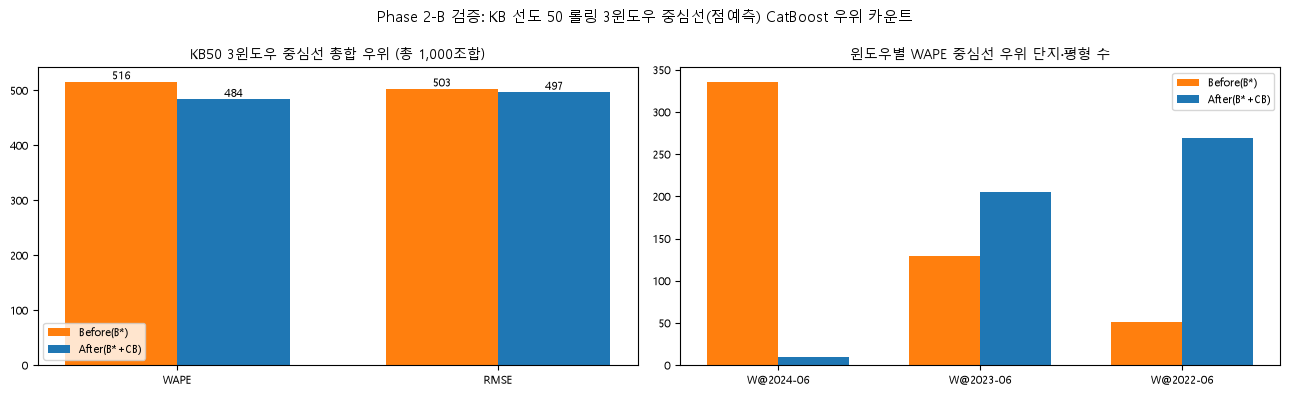

[phase2-B/KB50] 저장: module2/kb50_before_after_pointwise.csv, kb50_pointwise_wincounts.png


In [124]:
# ===== Phase 2-B 검증: KB 선도 50 전체 — AR 중심선(B*) vs CatBoost 중심선(B*+CB) 점예측 우위 (롤링 3윈도우) =====
# 위 5단지 시각검증을 거래활발 KB50 단지·평형 전체로 확장. Phase 1-D 와 동일한 BT_WINDOWS
# (W@2024-06·2023-06·2022-06, 8년 train→24개월 backtest)에서 중심선(점예측) RMSE·WAPE 비교·카운트.
# ★누수 차단: 윈도우마다 그 tr_end 이하 전역 패널로 h스텝 학습세트 재구성 + CatBoost 재학습 후
#   그 윈도우 backtest 구간(전부 tr_end 이후)만 예측. Before(B*)는 윈도우별 재적합이라 항상 정직.
_TARGET, _TIME = CFG.TARGET_COL, CFG.TIME_COL

# --- (1) KB50 패널(전체 기간, Before/After 평가용) ---
_kb50_panel_cache = os.path.join(CFG.OUT_ROOT, "module1", "kb50_panel_full.pkl")
if os.path.exists(_kb50_panel_cache):
    kb50_panel = pd.read_pickle(_kb50_panel_cache)
    print(f"[phase2-B/KB50] KB50 패널 캐시 로드: {kb50_panel.shape[0]:,}행")
else:
    kb50_panel = load_kb50_panel()
    kb50_panel.to_pickle(_kb50_panel_cache)
    print(f"[phase2-B/KB50] KB50 패널 적재·캐시: {kb50_panel.shape[0]:,}행")

# --- (2) 윈도우 재학습용 전역 패널(최대 tr_end 이하 1회 적재·캐시) ---
_max_tr_end = max(w["tr_end"] for w in BT_WINDOWS)
_pf_cache = os.path.join(CFG.OUT_ROOT, "module0", f"global_panel_cutoff_{_max_tr_end:%Y-%m}.pkl")
if os.path.exists(_pf_cache):
    panel_full = pd.read_pickle(_pf_cache)
    print(f"[phase2-B/KB50] 전역 패널(≤{_max_tr_end:%Y-%m}) 캐시 로드: {panel_full.shape[0]:,}행")
else:
    panel_full = load_global_panel(f"{_max_tr_end:%Y-%m-%d}")
    panel_full.to_pickle(_pf_cache)
    print(f"[phase2-B/KB50] 전역 패널(≤{_max_tr_end:%Y-%m}) 적재·캐시: {panel_full.shape[0]:,}행")


def _fit_window_catboost(tr_end):
    """tr_end 이하 전역 패널 → h스텝 학습세트(캐시) → CatBoost 재학습(캐시). 누수 없음.
    반환: (cb_model, hstep_trainset) — ts 는 Phase 2-D 윈도우별 혁신 풀 구성에도 사용."""
    tag = B_STAR.replace("-", "").replace("/", "")
    ts_cache = os.path.join(CFG.OUT_ROOT, "module2", f"hstep_trainset_{tag}_{tr_end:%Y-%m}.pkl")
    cb_cache = os.path.join(CFG.OUT_ROOT, "module2", f"catboost_residual_{tag}_{tr_end:%Y-%m}.cbm")
    # h스텝 학습세트(항상 확보 — 점예측 보정·혁신 풀 양쪽에 필요)
    if os.path.exists(ts_cache):
        ts = pd.read_pickle(ts_cache)
        print(f"    [resid] 캐시 로드: {len(ts):,}행 (≤{tr_end:%Y-%m})")
    else:
        sub = panel_full[panel_full[_TIME] <= tr_end]
        ts = build_hstep_trainset(sub, B_STAR)
        ts.to_pickle(ts_cache)
    if os.path.exists(cb_cache):
        cb = CatBoostRegressor(); cb.load_model(cb_cache)
        print(f"    [cb] 캐시 로드: catboost_residual_{tag}_{tr_end:%Y-%m}.cbm")
        return cb, ts
    _cut = ts[_TIME].max() - pd.DateOffset(months=12)
    m = ts[_TIME] <= _cut
    Xtr = _prep_features(ts[m]);  ytr = ts.loc[m, "resid_target"].values
    Xva = _prep_features(ts[~m]); yva = ts.loc[~m, "resid_target"].values
    ci = [Xtr.columns.get_loc(c) for c in CAT_FEATS]
    cb = CatBoostRegressor(
        iterations=CFG.CB_ITERATIONS, learning_rate=CFG.CB_LEARNING_RATE, depth=CFG.CB_DEPTH,
        l2_leaf_reg=CFG.CB_L2_LEAF_REG, loss_function="RMSE", random_seed=CFG.CB_RANDOM_SEED,
        task_type=CATBOOST_TASK_TYPE, od_type="Iter", od_wait=CFG.CB_EARLY_STOP, verbose=False)
    cb.fit(Pool(Xtr, ytr, cat_features=ci), eval_set=Pool(Xva, yva, cat_features=ci), use_best_model=True)
    cb.save_model(cb_cache)
    print(f"    [cb] 재학습 완료 best_iter={cb.get_best_iteration()}  valid RMSE={rmse(yva, cb.predict(Xva)):.5f}")
    return cb, ts


def _kb50_point_window(panel, w, cb):
    """KB50 각 단지×평형: 윈도우 w 의 [tr_start,tr_end] 학습 → [bt_start,bt_end] 24개월 중심선(점예측).
    Before=B* 점예측, After=B*+(윈도우 CatBoost) 보정. After 거시는 backtest 실현값(조건부)."""
    H = CFG.HORIZON
    tr_lo, tr_hi = w["tr_start"], w["tr_end"]
    te_lo, te_hi = w["bt_start"], w["bt_end"]
    out = []
    for keyvals, g in panel.groupby(GROUP_KEYS, sort=False):
        g = g.sort_values(_TIME).reset_index(drop=True)
        t = g[_TIME]
        tr = g[(t >= tr_lo) & (t <= tr_hi)]
        te = g[(t >= te_lo) & (t <= te_hi)].head(H)
        ytr = tr[_TARGET].astype(float).values
        yte = te[_TARGET].astype(float).values
        if len(tr) < CFG.MIN_TRAIN_MONTHS or len(te) < H or np.any(ytr <= 0) or np.any(yte <= 0):
            continue
        z_tr = np.log(ytr) if CFG.LOG_TARGET else ytr
        last = z_tr[-1]
        exog_tr = get_exog_array(tr)
        try:
            p_c = fit_select_ar(z_tr, CFG.AR_MAX_LAG, CFG.AR_IC)[0] if B_STAR == "AR" else None
            base_log = base_forecast_log(B_STAR, z_tr, H, exog_tr=exog_tr, p_ar=p_c)
        except Exception:
            continue
        if not np.all(np.isfinite(base_log)):
            continue
        feat = te.copy()
        feat[HSTEP_COL]      = np.arange(1, H + 1)
        feat["base_drift"]   = base_log - last
        feat["origin_last"]  = last
        feat["origin_mom3"]  = (last - z_tr[-4])  if len(z_tr) >= 4  else 0.0
        feat["origin_mom6"]  = (last - z_tr[-7])  if len(z_tr) >= 7  else 0.0
        feat["origin_mom12"] = (last - z_tr[-13]) if len(z_tr) >= 13 else 0.0
        try:
            corr = cb.predict(_prep_features(feat))
        except Exception:
            continue
        before_price = to_price_space(base_log)
        after_price  = to_price_space(base_log + corr)
        out.append({
            "윈도우": w["name"], "단지": "|".join(str(x) for x in keyvals),
            "RMSE_Before": rmse(yte, before_price), "RMSE_After": rmse(yte, after_price),
            "WAPE_Before": wape(yte, before_price), "WAPE_After": wape(yte, after_price),
        })
    return out


# --- (3) 윈도우 루프: 윈도우별 CatBoost 재학습 → KB50 중심선 Before/After ---
_rows = []
for w in BT_WINDOWS:
    print(f"\n[phase2-B/KB50] {w['name']}  {w['label']}")
    _cb_w, _ts_w = _fit_window_catboost(w["tr_end"])
    _wr = _kb50_point_window(kb50_panel, w, _cb_w)
    print(f"    → KB50 적합 케이스 {len(_wr):,}개")
    _rows.extend(_wr)
kb50_pt = pd.DataFrame(_rows)

# --- (4) 우위 카운트 (윈도우×단지 조합 = Phase 1-D 와 동일 단위) ---
n_kb = len(kb50_pt)
_win_w = int((kb50_pt["WAPE_After"] < kb50_pt["WAPE_Before"]).sum())
_win_r = int((kb50_pt["RMSE_After"] < kb50_pt["RMSE_Before"]).sum())
_tie_w = int((kb50_pt["WAPE_After"] == kb50_pt["WAPE_Before"]).sum())

print(f"\n=== KB50 × 롤링 3윈도우 : Before({B_STAR}) vs After({B_STAR}+CatBoost) 중심선 평균 ===")
_kb_summary = pd.DataFrame({
    "Before": [kb50_pt["RMSE_Before"].mean(), kb50_pt["WAPE_Before"].mean()],
    "After":  [kb50_pt["RMSE_After"].mean(),  kb50_pt["WAPE_After"].mean()],
}, index=["RMSE", "WAPE"])
_kb_summary["개선(Before-After)"] = _kb_summary["Before"] - _kb_summary["After"]
print(_kb_summary.round(4).to_string(float_format=lambda v: f"{v:,.4f}"))

print(f"\n=== 윈도우별 WAPE 중심선 우위 카운트 (After=CatBoost 보정이 더 정확) ===")
for w in BT_WINDOWS:
    sub = kb50_pt[kb50_pt["윈도우"] == w["name"]]
    nw = len(sub); aw = int((sub["WAPE_After"] < sub["WAPE_Before"]).sum())
    tw = int((sub["WAPE_After"] == sub["WAPE_Before"]).sum())
    print(f"  {w['name']} (n={nw:,}): After {aw:>4,} ({aw/max(nw,1):5.1%})  | Before {nw-aw-tw:,}  | 동률 {tw:,}")

print(f"\n=== 3윈도우 총합 중심선 우위 카운트 (총 {n_kb:,} 윈도우×단지·평형 조합) ===")
print(f"  WAPE 우위(After)  {_win_w:>5,} / {n_kb:,}  ({_win_w/max(n_kb,1):5.1%})   | Before {n_kb-_win_w-_tie_w:,}  | 동률 {_tie_w:,}")
print(f"  RMSE 우위(After)  {_win_r:>5,} / {n_kb:,}  ({_win_r/max(n_kb,1):5.1%})   | Before {n_kb-_win_r:,}")
kb50_pt.to_csv(os.path.join(CFG.OUT_ROOT, "module2", "kb50_before_after_pointwise.csv"),
               index=False, encoding="utf-8-sig")

# --- (5) 시각화: (좌) 총합 WAPE/RMSE 우위, (우) 윈도우별 WAPE 우위 ---
fig, axk = plt.subplots(1, 2, figsize=(13, 4))
_xg = np.arange(2); _wbar = 0.35
axk[0].bar(_xg - _wbar/2, [n_kb - _win_w - _tie_w, n_kb - _win_r], _wbar, label="Before(B*)", color="tab:orange")
axk[0].bar(_xg + _wbar/2, [_win_w, _win_r], _wbar, label="After(B*+CB)", color="tab:blue")
axk[0].set_xticks(_xg); axk[0].set_xticklabels(["WAPE", "RMSE"])
axk[0].set_title(f"KB50 3윈도우 중심선 총합 우위 (총 {n_kb:,}조합)", fontsize=10); axk[0].legend(fontsize=8)
for _xx, _vb, _va in zip(_xg, [n_kb-_win_w-_tie_w, n_kb-_win_r], [_win_w, _win_r]):
    axk[0].text(_xx - _wbar/2, _vb, f"{_vb:,}", ha="center", va="bottom", fontsize=8)
    axk[0].text(_xx + _wbar/2, _va, f"{_va:,}", ha="center", va="bottom", fontsize=8)
_wn = [w["name"] for w in BT_WINDOWS]
_aw = [int((kb50_pt[kb50_pt["윈도우"]==w["name"]]["WAPE_After"] < kb50_pt[kb50_pt["윈도우"]==w["name"]]["WAPE_Before"]).sum()) for w in BT_WINDOWS]
_bw = [len(kb50_pt[kb50_pt["윈도우"]==w["name"]]) - a for w, a in zip(BT_WINDOWS, _aw)]
_xw = np.arange(len(_wn))
axk[1].bar(_xw - _wbar/2, _bw, _wbar, label="Before(B*)", color="tab:orange")
axk[1].bar(_xw + _wbar/2, _aw, _wbar, label="After(B*+CB)", color="tab:blue")
axk[1].set_xticks(_xw); axk[1].set_xticklabels(_wn, fontsize=8)
axk[1].set_title("윈도우별 WAPE 중심선 우위 단지·평형 수", fontsize=10); axk[1].legend(fontsize=8)
for a in axk:
    a.tick_params(labelsize=8)
plt.suptitle("Phase 2-B 검증: KB 선도 50 롤링 3윈도우 중심선(점예측) CatBoost 우위 카운트", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUT_ROOT, "module2", "kb50_pointwise_wincounts.png"), dpi=110, bbox_inches="tight")
plt.show()
print("[phase2-B/KB50] 저장: module2/kb50_before_after_pointwise.csv, kb50_pointwise_wincounts.png")


## Phase 2-C. 밴드(확률예측) 평가 지표

점예측(RMSE·WAPE) 외에 **분포/구간 품질**을 채점한다. 모두 **작을수록 좋음**.

**① 핀볼(분위) 손실** — 분위수 $q$ 예측 $\hat y_q$ 의 정확도:
$$L_q(y,\hat y_q)=\max\!\big(q\,(y-\hat y_q),\,(q-1)(y-\hat y_q)\big)$$
여러 분위수 평균(Quantile/CRPS 근사). 비대칭 벌점 — 과소·과대 예측을 분위수에 맞게 다르게 벌함.

**② Winkler 구간점수** — $(1-\alpha)$ 예측구간 $[L,U]$ (여기선 $\alpha=0.2$, 80% PI):
$$W_\alpha=(U-L)+\frac{2}{\alpha}\big[(L-y)\,\mathbf{1}_{y<L}+(y-U)\,\mathbf{1}_{y>U}\big]$$
구간이 좁을수록·실제값을 잘 덮을수록 작다. 폭과 커버리지를 **동시에** 채점.

**③ CRPS (경험적 앙상블)** — 부트스트랩 표본 $\{x_i\}_{i=1}^m$ 과 관측 $y$:
$$\text{CRPS}=\frac1m\sum_i|x_i-y|-\frac{1}{2m^2}\sum_{i,j}|x_i-x_j|$$
점예측의 MAE를 분포로 일반화 — 전체 예측분포의 정합성을 본다.


In [125]:
def pinball_loss(y_true, q_pred, q: float) -> float:
    """분위수 q 의 핀볼(분위) 손실 평균. 작을수록 좋음."""
    y = np.asarray(y_true, float); yq = np.asarray(q_pred, float)
    e = y - yq
    return float(np.mean(np.maximum(q * e, (q - 1.0) * e)))


def mean_pinball(y_true, q_preds: dict) -> float:
    """여러 분위수 평균 핀볼. q_preds = {q: 예측배열}."""
    return float(np.mean([pinball_loss(y_true, p, q) for q, p in q_preds.items()]))


def winkler_score(y_true, lower, upper, alpha: float) -> float:
    """(1-alpha) 예측구간 [L,U] 의 Winkler 구간점수 평균. 폭+커버리지 동시 채점."""
    y = np.asarray(y_true, float); L = np.asarray(lower, float); U = np.asarray(upper, float)
    s = (U - L).astype(float)
    below = y < L; above = y > U
    s[below] += (2.0 / alpha) * (L[below] - y[below])
    s[above] += (2.0 / alpha) * (y[above] - U[above])
    return float(np.mean(s))


def coverage(y_true, lower, upper) -> float:
    """구간이 실제값을 덮는 비율(명목 1-alpha 와 비교)."""
    y = np.asarray(y_true, float); L = np.asarray(lower, float); U = np.asarray(upper, float)
    return float(np.mean((y >= L) & (y <= U)))


def crps_ensemble(y_true, ensemble) -> float:
    """경험적 앙상블 CRPS 평균. ensemble: (n_obs, m). 정렬기반 O(m log m).
    CRPS = E|X-y| - 0.5 E|X-X'|."""
    y = np.asarray(y_true, float)
    E = np.asarray(ensemble, float)
    if E.ndim == 1:
        E = E[None, :]
    t1 = np.mean(np.abs(E - y[:, None]), axis=1)              # E|X - y|
    Es = np.sort(E, axis=1)
    m = E.shape[1]
    w = (2 * np.arange(m) - m + 1).astype(float)              # sum_{i<j}(x_j-x_i) 가중치
    pair = np.sum(w[None, :] * Es, axis=1)                    # = sum_{i<j}|x_i-x_j|
    t2 = pair / (m * m)                                       # 0.5 * E|X-X'|
    return float(np.mean(t1 - t2))


print("[phase2-C] 밴드 지표 준비: pinball_loss, mean_pinball, winkler_score, coverage, crps_ensemble")


[phase2-C] 밴드 지표 준비: pinball_loss, mean_pinball, winkler_score, coverage, crps_ensemble


## Phase 2-D. B\* 예측 + 공유 부트스트랩 밴드 (Before / After CatBoost)

**구조** : 단지별 B\* 점예측(로그) → (After 만) CatBoost h스텝 오차보정 → **마지막에 블록 부트스트랩으로 밴드**.

#### ① 점예측(P50 중심경로)
$$\widehat{\log P}_{t_0+h} \;=\; \underbrace{B^{*}\text{ 외삽}}_{\text{base\_log}_h} \;+\; \underbrace{f_{\text{CB}}\!\big(\text{거시}_{t_0+h},\,\text{Static},\,h,\,\text{원점추세}\big)}_{\text{보정}_h\ (\text{After 만})}$$
- 거시(D1/D2/D3)는 **예측구간 실현값**(test) 사용 → 조건부예측(비대칭은 Phase 2 서두에 명시).
- 원점추세 피처(`base_drift`, `origin_*`)는 학습세트와 **동일 정의**로 재현 → 누수 없음.

#### ② 공유 부트스트랩 엔진 (엔진 하나, 혁신 풀만 교체)
혁신 풀 = **h스텝 오차의 1스텝 증분**. (1스텝 잔차는 백색화되어 밴드가 비현실적으로 좁아지므로
h스텝 오차 증분으로 교체해 진짜 예측 불확실성을 반영.)
- **Before** : B\* 의 **원시 h스텝 오차증분** (`resid_train["resid_target"]`).
- **After**  : B\*+CatBoost **보정 후 오차증분** (`resid_target - cb_pred`).

오차 궤적 $E_1,\dots,E_k$ 의 증분 $d_h=E_h-E_{h-1}$ ($E_0{=}0$)을 풀로 모아 **평균 0으로 중심화**(P50=점예측 유지).
블록(길이 `BLOCK_SIZE=3`) 복원추출 → horizon 길이 → **cumsum**:
$$\log P^{(b)}_{t_0+h} \;=\; \widehat{\log P}_{t_0+h} \;+\; \sum_{j=1}^{h}\varepsilon^{(b)}_j,\qquad \varepsilon^{(b)} \sim \text{block-resample}(\{d_h-\bar d\})$$
- `N_BOOTSTRAP=1000` 경로. **엔진/필터는 Before/After 공유, 풀만 교체.**

#### ③ 현실성 필터 (위반 경로 drop)
원점 직전 실제값을 앵커로, 각 스텝 월간변동률 $\,r_h=\exp(\Delta\log P_h)-1\,$ 이
$|r_h|>\text{REALISM\_MAX\_MOM}(0.25)$ 인 경로는 분포에서 **제거**(`REALISM_DROP=True`).

In [126]:
# ===== 공유 부트스트랩 엔진 (두 모델 공통) =====
def block_bootstrap_innovations(resid_pool: np.ndarray, horizon: int,
                                n_boot: int, block: int, rng: np.random.Generator) -> np.ndarray:
    """1스텝 잔차 풀에서 길이=block 블록을 복원추출해 horizon 길이로 이어붙임 → (n_boot, horizon).
    각 행은 누적 전(innovation) 단계별 충격."""
    pool = np.asarray(resid_pool, float)
    pool = pool[np.isfinite(pool)]
    L = len(pool)
    n_blocks = int(np.ceil(horizon / block))
    starts = rng.integers(0, max(1, L - block + 1), size=(n_boot, n_blocks))
    out = np.empty((n_boot, n_blocks * block), float)
    for j in range(n_blocks):
        s = starts[:, j]
        for k in range(block):
            out[:, j * block + k] = pool[np.minimum(s + k, L - 1)]
    return out[:, :horizon]


def realism_keep_mask(ensemble_log: np.ndarray, origin_log: float, max_mom: float) -> np.ndarray:
    """각 경로의 월간변동률 |exp(Δlogp)-1|<=max_mom 이면 유지. 원점 직전 실제값을 앵커로."""
    anchor = np.full((ensemble_log.shape[0], 1), origin_log, float)
    full = np.concatenate([anchor, ensemble_log], axis=1)     # (n, H+1)
    mom = np.exp(np.diff(full, axis=1)) - 1.0                  # (n, H)
    return np.all(np.abs(mom) <= max_mom, axis=1)


def make_bands(point_log: np.ndarray, resid_pool: np.ndarray, origin_log: float,
               seed_offset: int = 0) -> dict:
    """점예측(로그) + 1스텝 잔차풀 → 블록부트스트랩 → 현실성필터 → 분위 밴드(원단위).
    반환: {'q': {0.1/0.5/0.9: 가격(H,)}, 'ensemble': 가격(n_keep,H), 'n_keep','n_drop','point': 가격(H,)}."""
    H = len(point_log)
    rng = np.random.default_rng(CFG.BOOTSTRAP_SEED + seed_offset)
    innov = block_bootstrap_innovations(resid_pool, H, CFG.N_BOOTSTRAP, CFG.BLOCK_SIZE, rng)
    ens_log = point_log[None, :] + np.cumsum(innov, axis=1)    # 점예측 중심 + 혁신 산포
    if CFG.REALISM_DROP:
        keep = realism_keep_mask(ens_log, origin_log, CFG.REALISM_MAX_MOM)
        n_drop = int((~keep).sum())
        if keep.sum() >= 20:        # 너무 적게 남으면 필터 무력화(분위 불안정 방지)
            ens_log = ens_log[keep]
        else:
            n_drop = 0
    else:
        n_drop = 0
    ens_price = to_price_space(ens_log)
    qs = {q: np.quantile(ens_price, q, axis=0) for q in CFG.QUANTILES}
    return {"q": qs, "ensemble": ens_price, "n_keep": ens_price.shape[0],
            "n_drop": n_drop, "point": to_price_space(point_log)}


def error_increment_pool(resid_df: pd.DataFrame, post_err: np.ndarray) -> np.ndarray:
    """보정 후 h스텝 오차 궤적의 1스텝 증분 d_h=E_h-E_{h-1} (E_0=0)을 origin별로 모아 평균0 중심화.
    origin = 실현월 - h_step. 블록부트스트랩 cumsum 시 실제 h스텝 오차분산을 복원하는 혁신 풀."""
    tmp = resid_df[GROUP_KEYS].copy()
    realized = resid_df[CFG.TIME_COL].dt.to_period("M")
    tmp["origin"] = (realized - resid_df[HSTEP_COL].astype(int)).astype(str)
    tmp["h"] = resid_df[HSTEP_COL].astype(int).values
    tmp["post"] = np.asarray(post_err, float)
    incrs = []
    for _, gg in tmp.sort_values("h").groupby(GROUP_KEYS + ["origin"], sort=False):
        E = gg["post"].values
        d = np.empty_like(E); d[0] = E[0]
        if len(E) > 1:
            d[1:] = np.diff(E)
        incrs.append(d)
    pool = np.concatenate(incrs) if incrs else np.zeros(1)
    return pool - pool.mean()        # 평균0 중심화 → P50≈점예측


print("[phase2-D] 공유 부트스트랩 엔진 준비: block_bootstrap_innovations, realism_keep_mask, make_bands, error_increment_pool")


[phase2-D] 공유 부트스트랩 엔진 준비: block_bootstrap_innovations, realism_keep_mask, make_bands, error_increment_pool


In [127]:
# ===== B* 추론: Before(부트스트랩만) vs After(CatBoost 보정 + 부트스트랩) =====
# 혁신 풀(전역, 1회): Before=B* 원시 오차증분, After=보정후 오차증분 → 공유 엔진에 주입
_post_err = resid_train["resid_target"].values - cb_model.predict(_prep_features(resid_train))
BEFORE_INNOV_POOL = error_increment_pool(resid_train, resid_train["resid_target"].values)  # 원시 B* 오차
AFTER_INNOV_POOL  = error_increment_pool(resid_train, _post_err)                             # 보정 후 오차
print(f"[before] 혁신 풀(원시 B* 오차증분): n={len(BEFORE_INNOV_POOL):,}  std={BEFORE_INNOV_POOL.std():.4f}  "
      f"(cumsum 24스텝 std≈{BEFORE_INNOV_POOL.std()*np.sqrt(CFG.HORIZON):.3f})")
print(f"[after ] 혁신 풀(보정후 오차증분): n={len(AFTER_INNOV_POOL):,}  std={AFTER_INNOV_POOL.std():.4f}  "
      f"(cumsum 24스텝 std≈{AFTER_INNOV_POOL.std()*np.sqrt(CFG.HORIZON):.3f})")


def bstar_forecast(key: str, st: dict, use_catboost: bool, innov_pool: np.ndarray) -> dict:
    """B* 점예측 → (use_catboost면) CatBoost 보정 → 공유 부트스트랩 밴드."""
    train_df = st["train"]; test_df = st["test"].sort_values(CFG.TIME_COL).reset_index(drop=True)
    z_tr = to_model_space(get_target_series(train_df).values)
    exog_tr = get_exog_array(train_df)
    p_c = ar_orders[key]
    H = min(CFG.HORIZON, len(test_df))
    last = z_tr[-1]

    # ① B* 점예측(로그)
    base_log = base_forecast_log(B_STAR, z_tr, H, exog_tr=exog_tr, p_ar=p_c)

    # ② (After만) CatBoost h스텝 오차보정 — 학습세트와 동일 피처 정의로 재현
    if use_catboost:
        feat = test_df.iloc[:H].copy()
        feat[HSTEP_COL]      = np.arange(1, H + 1)
        feat["base_drift"]   = base_log - last
        feat["origin_last"]  = last
        feat["origin_mom3"]  = (last - z_tr[-4])  if len(z_tr) >= 4  else 0.0
        feat["origin_mom6"]  = (last - z_tr[-7])  if len(z_tr) >= 7  else 0.0
        feat["origin_mom12"] = (last - z_tr[-13]) if len(z_tr) >= 13 else 0.0
        point_log = base_log + cb_model.predict(_prep_features(feat))
    else:
        point_log = base_log

    # ③ 공유 부트스트랩 → 밴드 (현실성 필터 포함)
    seed_off = abs(hash(key)) % 1000
    bands = make_bands(point_log, innov_pool, origin_log=last, seed_offset=seed_off)

    actual = test_df[CFG.TARGET_COL].astype(float).values[:H]
    dates  = test_df[CFG.TIME_COL].values[:H]
    return {"key": key, "H": H, "dates": dates, "actual": actual,
            "base_price": to_price_space(base_log), "point": bands["point"],
            "P10": bands["q"][0.1], "P50": bands["q"][0.5], "P90": bands["q"][0.9],
            "ensemble": bands["ensemble"], "n_keep": bands["n_keep"], "n_drop": bands["n_drop"]}


def score_bands(r: dict) -> dict:
    y = r["actual"]
    q_preds = {0.1: r["P10"], 0.5: r["P50"], 0.9: r["P90"]}
    return {
        "RMSE":   rmse(y, r["P50"]),
        "WAPE":   wape(y, r["P50"]),
        "Pinball": mean_pinball(y, q_preds),
        "Winkler": winkler_score(y, r["P10"], r["P90"], CFG.PI_ALPHA),
        "Cover80": coverage(y, r["P10"], r["P90"]),
        "CRPS":   crps_ensemble(y, r["ensemble"].T),
    }


def _run_side(use_catboost: bool, innov_pool: np.ndarray, tag: str):
    results, rows = {}, []
    for key, st in series_store.items():
        r = bstar_forecast(key, st, use_catboost, innov_pool)
        results[key] = r
        m = score_bands(r)
        m["단지"] = f"{st['gu']} {st['name']}"; m["drop%"] = 100 * r["n_drop"] / CFG.N_BOOTSTRAP
        rows.append(m)
    df = pd.DataFrame(rows).set_index("단지")[
        ["RMSE", "WAPE", "Pinball", "Winkler", "Cover80", "CRPS", "drop%"]]
    return results, df


# Before = B* + 부트스트랩(보정 없음) / After = B* + CatBoost + 부트스트랩
before_results, before_df = _run_side(False, BEFORE_INNOV_POOL, "before")
after_results,  after_df  = _run_side(True,  AFTER_INNOV_POOL,  "after")

print(f"\n=== Before: {B_STAR} + 부트스트랩 (CatBoost 미적용) ===")
print(before_df.round(4).to_string())
print(f"\n=== After: {B_STAR} + CatBoost + 부트스트랩 ===")
print(after_df.round(4).to_string())
print(f"\n[before] 평균  WAPE={before_df['WAPE'].mean():.4f}  CRPS={before_df['CRPS'].mean():,.0f}  Cover80={before_df['Cover80'].mean():.2f}")
print(f"[after ] 평균  WAPE={after_df['WAPE'].mean():.4f}  CRPS={after_df['CRPS'].mean():,.0f}  Cover80={after_df['Cover80'].mean():.2f}")
before_df.to_csv(os.path.join(CFG.OUT_ROOT, "module2", "before_band_metrics.csv"), encoding="utf-8-sig")
after_df.to_csv(os.path.join(CFG.OUT_ROOT, "module2", "after_band_metrics.csv"), encoding="utf-8-sig")

[before] 혁신 풀(원시 B* 오차증분): n=1,066,066  std=0.0380  (cumsum 24스텝 std≈0.186)
[after ] 혁신 풀(보정후 오차증분): n=1,066,066  std=0.0291  (cumsum 24스텝 std≈0.142)

=== Before: AR + 부트스트랩 (CatBoost 미적용) ===
                     RMSE    WAPE     Pinball      Winkler  Cover80        CRPS  drop%
단지                                                                                    
강남구 현대6,7차     89136.5498  0.1186  19592.4280  261016.2514    0.750  44742.9461    6.5
강동구 강동롯데캐슬퍼스트   8008.8235  0.0474   2406.3672   40163.2415    1.000   4822.3975    5.8
마포구 마포래미안푸르지오  16313.4016  0.0729   4051.0187   53761.5544    1.000   8675.1547    5.0
서초구 래미안퍼스티지    48796.5699  0.0991  10677.1185  127424.6131    0.875  25013.4226    5.9
송파구 잠실주공5단지    48991.5425  0.1224  10686.2820  135506.4827    0.750  24844.9867    6.5

=== After: AR + CatBoost + 부트스트랩 ===
                     RMSE    WAPE     Pinball      Winkler  Cover80        CRPS  drop%
단지                                                                       

### Phase 2-D 시각화 + KB 선도 50 밴드 검증 (부트스트랩 후)

위 Before/After 밴드지표(텍스트)에 더해 두 가지로 보강한다.

1. **선택 5단지 시계열** : Before(B\*) 와 After(B\*+CatBoost) 의 **중앙경로(P50)** 를 실제값과 겹쳐
   CatBoost 부스팅이 실제 시세에 더 가까워지는지 시각 검증한다.
2. **KB 선도 50 밴드 우위 카운트 (롤링 3윈도우)** : Phase 2-B 가 **중심선(점예측)** 을 비교했다면,
   여기서는 **공유 블록 부트스트랩으로 밴드를 씌운 뒤** 평가한다 →
   **Before = B\*+부트스트랩(AR+Boot)** vs **After = B\*+CatBoost+부트스트랩(AR+CB+Boot)**, **P50 중심**.
   Phase 1-D 와 **동일한 `BT_WINDOWS`**(W@2024-06 · W@2023-06 · W@2022-06, 각 8년 train → 24개월
   backtest)에서 거래활발 KB50 단지·평형 **전체**의 **6지표** 우위를 센다.
   - **6지표** : `RMSE` · `WAPE` (점/중심선) + `Pinball` · `Winkler` · `Cover80` · `CRPS` (분포·구간 품질).
     RMSE/WAPE/Pinball/Winkler/CRPS 는 **작을수록 우위**, **Cover80 은 명목 80%에 가까울수록 우위**
     ($|cov-0.8|$ 작은 쪽). 총합·윈도우별로 After 우위 조합수를 카운트하고 bar chart 로 시각화한다.
   - **누수 차단** : 각 윈도우마다 그 `tr_end` 이하 학습세트로 **재학습된 CatBoost** 와, 그 윈도우
     h스텝 학습세트에서 구성한 **혁신 풀(Before=원시 오차증분 / After=보정후 오차증분)** 만 사용한다.
     → 과거 윈도우(2022·2023)에서도 After 가 미래를 보지 않는다. (Before=B\* 는 윈도우별 재적합이라 항상 정직)
   - 설정(`kb50_panel` · `panel_full` · `_fit_window_catboost`)과 윈도우별 캐시(`catboost_residual_*.cbm`)는
     Phase 2-B 에서 만든 것을 재사용한다.


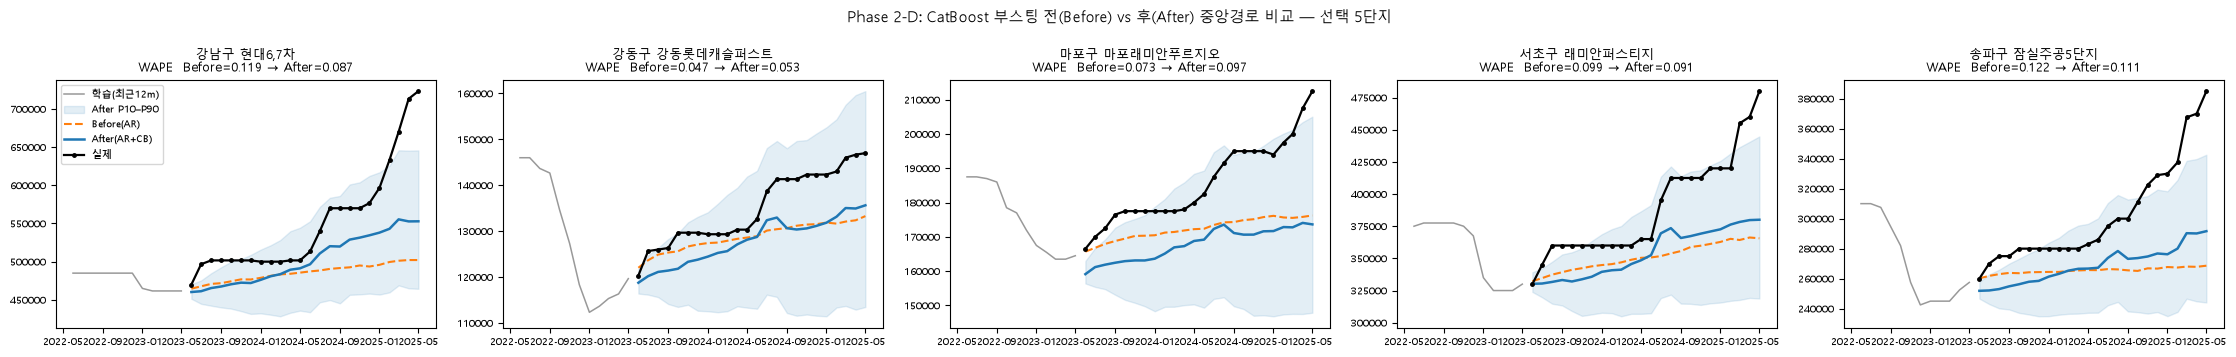

In [128]:
# ===== Phase 2-D 시각화: 선택 5단지 — Before(B*) vs After(B*+CatBoost) 시계열 =====
# 위 셀의 텍스트 표에 더해, Before/After 중앙경로(P50)와 실제값을 시계열로 겹쳐
# "CatBoost 부스팅이 실제값에 더 가까워지는가" 를 단지별로 시각 검증한다.
fig, axes = plt.subplots(1, len(series_store), figsize=(4.5 * len(series_store), 3.6), squeeze=False)
for ax, (key, st) in zip(axes[0], series_store.items()):
    rb = before_results[key]; ra = after_results[key]
    x = pd.to_datetime(ra["dates"])
    s_tr = get_target_series(st["train"]).iloc[-12:]
    ax.plot(s_tr.index, s_tr.values, color="0.6", lw=1.1, label="학습(최근12m)")
    ax.fill_between(x, ra["P10"], ra["P90"], color="tab:blue", alpha=0.12, label="After P10–P90")
    ax.plot(x, rb["P50"], color="tab:orange", ls="--", lw=1.5, label=f"Before({B_STAR})")
    ax.plot(x, ra["P50"], color="tab:blue", lw=1.8, label=f"After({B_STAR}+CB)")
    ax.plot(x, ra["actual"], color="black", marker="o", ms=2.5, lw=1.6, label="실제")
    wb = wape(rb["actual"], rb["P50"]); wa = wape(ra["actual"], ra["P50"])
    ax.set_title(f"{st['gu']} {st['name']}\nWAPE  Before={wb:.3f} → After={wa:.3f}", fontsize=9)
    ax.tick_params(labelsize=7)
axes[0][0].legend(fontsize=7, loc="best")
plt.suptitle("Phase 2-D: CatBoost 부스팅 전(Before) vs 후(After) 중앙경로 비교 — 선택 5단지", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUT_ROOT, "module2", "before_after_trend.png"), dpi=110, bbox_inches="tight")
plt.show()


In [ ]:
# ===== Phase 2-D 검증: KB 선도 50 — Before(AR+Boot) vs After(AR+CB+Boot) 밴드 우위 (롤링 3윈도우) =====
# Phase 2-B 가 중심선(점예측)을 비교했다면, 여기서는 공유 블록 부트스트랩으로 밴드를 씌운 뒤
# 분포·구간 품질까지 6지표(RMSE·WAPE·Pinball·Winkler·Cover80·CRPS)로 우위를 카운트한다.
# ★ 평가 대상은 '부트스트랩 후' : Before = B*+부트스트랩,  After = B*+CatBoost+부트스트랩 (P50 중심).
# ★ 누수 차단: 윈도우마다 그 tr_end 이하 학습세트로 재학습된 CatBoost + 그 윈도우 h스텝 학습세트에서
#   구성한 혁신 풀(Before/After)만 사용 → 과거 윈도우가 미래를 보지 않음.
#   (kb50_panel · panel_full · _fit_window_catboost 는 Phase 2-B 에서 정의·캐시됨 → 재사용)

# 6지표: 5개는 작을수록 우위, Cover80 은 명목(1-alpha)에 가까울수록 우위
BAND_METRICS  = ["RMSE", "WAPE", "Pinball", "Winkler", "Cover80", "CRPS"]
_LOWER_BETTER = {"RMSE", "WAPE", "Pinball", "Winkler", "CRPS"}
_NOMINAL_COV  = 1.0 - CFG.PI_ALPHA


def _score6(y, bands) -> dict:
    """밴드 6지표. P50=중심, P10/P90=80% 구간, ensemble=경험 분포."""
    q_preds = {0.1: bands["q"][0.1], 0.5: bands["q"][0.5], 0.9: bands["q"][0.9]}
    return {
        "RMSE":    rmse(y, bands["q"][0.5]),
        "WAPE":    wape(y, bands["q"][0.5]),
        "Pinball": mean_pinball(y, q_preds),
        "Winkler": winkler_score(y, bands["q"][0.1], bands["q"][0.9], CFG.PI_ALPHA),
        "Cover80": coverage(y, bands["q"][0.1], bands["q"][0.9]),
        "CRPS":    crps_ensemble(y, bands["ensemble"].T),
    }


def _after_wins(df, metric) -> np.ndarray:
    """After 가 우위인 조합 마스크. lower-better 는 작을수록, Cover80 은 명목에 가까울수록."""
    b = df[f"{metric}_Before"].values; a = df[f"{metric}_After"].values
    if metric in _LOWER_BETTER:
        return a < b
    return np.abs(a - _NOMINAL_COV) < np.abs(b - _NOMINAL_COV)


def _kb50_bands_window(panel, w, cb, before_pool, after_pool) -> list:
    """KB50 각 단지×평형: 윈도우 w 의 [tr_start,tr_end] 학습 → [bt_start,bt_end] 24개월.
    Before = B* 점예측 + (윈도우 Before풀) 부트스트랩 밴드,
    After  = B*+CatBoost 보정 + (윈도우 After풀) 부트스트랩 밴드. 각 6지표 산출."""
    H = CFG.HORIZON
    tr_lo, tr_hi = w["tr_start"], w["tr_end"]
    te_lo, te_hi = w["bt_start"], w["bt_end"]
    out = []
    for keyvals, g in panel.groupby(GROUP_KEYS, sort=False):
        g = g.sort_values(_TIME).reset_index(drop=True)
        t = g[_TIME]
        tr = g[(t >= tr_lo) & (t <= tr_hi)]
        te = g[(t >= te_lo) & (t <= te_hi)].head(H)
        ytr = tr[_TARGET].astype(float).values
        yte = te[_TARGET].astype(float).values
        if len(tr) < CFG.MIN_TRAIN_MONTHS or len(te) < H or np.any(ytr <= 0) or np.any(yte <= 0):
            continue
        z_tr = np.log(ytr) if CFG.LOG_TARGET else ytr
        last = z_tr[-1]
        exog_tr = get_exog_array(tr)
        try:
            p_c = fit_select_ar(z_tr, CFG.AR_MAX_LAG, CFG.AR_IC)[0] if B_STAR == "AR" else None
            base_log = base_forecast_log(B_STAR, z_tr, H, exog_tr=exog_tr, p_ar=p_c)
        except Exception:
            continue
        if not np.all(np.isfinite(base_log)):
            continue
        feat = te.copy()
        feat[HSTEP_COL]      = np.arange(1, H + 1)
        feat["base_drift"]   = base_log - last
        feat["origin_last"]  = last
        feat["origin_mom3"]  = (last - z_tr[-4])  if len(z_tr) >= 4  else 0.0
        feat["origin_mom6"]  = (last - z_tr[-7])  if len(z_tr) >= 7  else 0.0
        feat["origin_mom12"] = (last - z_tr[-13]) if len(z_tr) >= 13 else 0.0
        try:
            corr = cb.predict(_prep_features(feat))
        except Exception:
            continue
        seed_off = abs(hash(("|".join(str(x) for x in keyvals), w["name"]))) % 100000
        rb = make_bands(base_log,        before_pool, origin_log=last, seed_offset=seed_off)
        ra = make_bands(base_log + corr, after_pool,  origin_log=last, seed_offset=seed_off)
        mb, ma = _score6(yte, rb), _score6(yte, ra)
        row = {"윈도우": w["name"], "단지": "|".join(str(x) for x in keyvals)}
        for k in BAND_METRICS:
            row[f"{k}_Before"] = mb[k]; row[f"{k}_After"] = ma[k]
        out.append(row)
    return out


# --- 윈도우 루프: 윈도우별 CatBoost·혁신 풀 → KB50 밴드 6지표 ---
_rows = []
for w in BT_WINDOWS:
    #print(f"\n[phase2-D/KB50] {w['name']}  {w['label']}")
    _cb_w, _ts_w = _fit_window_catboost(w["tr_end"])
    _post = _ts_w["resid_target"].values - _cb_w.predict(_prep_features(_ts_w))
    _before_pool = error_increment_pool(_ts_w, _ts_w["resid_target"].values)   # 원시 B* 오차증분
    _after_pool  = error_increment_pool(_ts_w, _post)                          # 보정 후 오차증분
    #print(f"    [pool] Before std={_before_pool.std():.4f}  After std={_after_pool.std():.4f}")
    _wr = _kb50_bands_window(kb50_panel, w, _cb_w, _before_pool, _after_pool)
    #print(f"    → KB50 적합 케이스 {len(_wr):,}개")
    _rows.extend(_wr)
kb50_ba = pd.DataFrame(_rows)
n_kb = len(kb50_ba)

# --- 6지표 평균 + 우위 카운트 (윈도우×단지 조합) ---
print(f"\n=== KB50 × 롤링 3윈도우 밴드 6지표 평균 : Before(AR+Boot) vs After(AR+CB+Boot) ===")
_mean_df = pd.DataFrame(
    [{"지표": k, "Before": kb50_ba[f"{k}_Before"].mean(), "After": kb50_ba[f"{k}_After"].mean()}
     for k in BAND_METRICS]).set_index("지표")
_mean_df["개선(Before-After)"] = _mean_df["Before"] - _mean_df["After"]
print(_mean_df.round(4).to_string(float_format=lambda v: f"{v:,.4f}"))
print(f"  · RMSE/WAPE/Pinball/Winkler/CRPS = 작을수록 우위   · Cover80 = 명목 {_NOMINAL_COV:.2f} 근접이 우위(개선부호 무의미)")

_total_wins = {k: int(_after_wins(kb50_ba, k).sum()) for k in BAND_METRICS}
print(f"\n=== 6지표 After 우위 카운트 (총 {n_kb:,} 윈도우×단지·평형 조합) ===")
for k in BAND_METRICS:
    aw = _total_wins[k]
    print(f"  {k:8s}: After {aw:>5,} ({aw/max(n_kb,1):5.1%})  | Before {n_kb-aw:,}")

print(f"\n=== 윈도우별 After 우위율 (After=CatBoost 밴드가 더 우수) ===")
for w in BT_WINDOWS:
    sub = kb50_ba[kb50_ba["윈도우"] == w["name"]]
    parts = [f"{k} {_after_wins(sub, k).mean():4.0%}" for k in BAND_METRICS]
    print(f"  {w['name']} (n={len(sub):,}): " + " | ".join(parts))
kb50_ba.to_csv(os.path.join(CFG.OUT_ROOT, "module2", "kb50_before_after_bands.csv"),
               index=False, encoding="utf-8-sig")

# --- 시각화: (좌) 총합 6지표 우위, (우) 윈도우별 6지표 After 우위율 ---
fig, axk = plt.subplots(1, 2, figsize=(15, 4.4))
_xm = np.arange(len(BAND_METRICS)); _wbar = 0.38
_bef = [n_kb - _total_wins[k] for k in BAND_METRICS]
_aft = [_total_wins[k] for k in BAND_METRICS]
axk[0].bar(_xm - _wbar/2, _bef, _wbar, label="Before(AR+Boot)", color="tab:orange")
axk[0].bar(_xm + _wbar/2, _aft, _wbar, label="After(AR+CB+Boot)", color="tab:blue")
axk[0].set_xticks(_xm); axk[0].set_xticklabels(BAND_METRICS, fontsize=8)
axk[0].set_title(f"KB50 3윈도우 밴드 6지표 총합 우위 (총 {n_kb:,}조합)", fontsize=10); axk[0].legend(fontsize=8)
for _xx, _vb, _va in zip(_xm, _bef, _aft):
    axk[0].text(_xx - _wbar/2, _vb, f"{_vb:,}", ha="center", va="bottom", fontsize=7)
    axk[0].text(_xx + _wbar/2, _va, f"{_va:,}", ha="center", va="bottom", fontsize=7)
# 우: 윈도우별 After 우위율(%) — 지표 x축, 윈도우 그룹
_nw = len(BT_WINDOWS); _gw = 0.8 / _nw
for i, w in enumerate(BT_WINDOWS):
    sub = kb50_ba[kb50_ba["윈도우"] == w["name"]]
    rates = [100 * _after_wins(sub, k).mean() for k in BAND_METRICS]
    axk[1].bar(_xm + (i - (_nw - 1) / 2) * _gw, rates, _gw, label=w["name"])
axk[1].axhline(50, color="0.5", ls=":", lw=1)
axk[1].set_xticks(_xm); axk[1].set_xticklabels(BAND_METRICS, fontsize=8)
axk[1].set_ylabel("After 우위율 (%)", fontsize=9); axk[1].set_ylim(0, 100)
axk[1].set_title("윈도우별 6지표 After 우위율", fontsize=10); axk[1].legend(fontsize=8)
for a in axk:
    a.tick_params(labelsize=8)
plt.suptitle("Phase 2-D 검증: KB 선도 50 롤링 3윈도우 밴드(부트스트랩) 6지표 우위 카운트", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUT_ROOT, "module2", "kb50_bands_wincounts.png"), dpi=110, bbox_inches="tight")
plt.show()
print("[phase2-D/KB50] 저장: module2/kb50_before_after_bands.csv, kb50_bands_wincounts.png")


    [resid] 캐시 로드: 1,191,210행 (≤2024-05)
    [cb] 캐시 로드: catboost_residual_AR_2024-05.cbm


## Phase 2-F. 최종 결과 — `B* + CatBoost + 부트스트랩`

파이프라인의 **최종 산출물**을 정리한다. **B\* 점예측 → CatBoost h스텝 오차보정 → 블록 부트스트랩 밴드**
를 모두 거친 결과(= 위 **After**)에 대해, 선택 **5개 단지·24개월 백테스트**에서

- **점예측** : RMSE · WAPE
- **밴드품질** : Pinball · Winkler · CRPS · Cover80

을 한 표로 보고하고, **트렌드(팬)차트**로 실제값 대비 P10/P50/P90 밴드를 시각화하며 마무리한다.
(모든 지표 **작을수록 좋음**, Cover80 은 명목 0.80 근접이 이상적. Before 와의 비교는 Phase 2-D 에서 다룬다.)


=== 최종 밴드 예측 성능: AR + CatBoost + 부트스트랩 (5개 단지) ===
                     RMSE    WAPE     Pinball      Winkler  Cover80        CRPS
강남구 현대6,7차     64103.1498  0.0869  14832.3244  205461.5707   0.6667  33230.2508
강동구 강동롯데캐슬퍼스트   7908.2157  0.0532   2164.2182   29006.4091   0.9167   4593.8744
마포구 마포래미안푸르지오  19651.3863  0.0968   4690.6463   50788.0974   0.5000  11719.4620
서초구 래미안퍼스티지    42179.2562  0.0906   9945.3638  121946.0397   0.6667  23446.6022
송파구 잠실주공5단지    40675.5272  0.1106  10034.2667  133833.9015   0.4167  22911.3663
■ 평균(5단지)      34903.5070  0.0876   8333.3639  108207.2037   0.6333  19180.3111
  · RMSE/WAPE/Pinball/Winkler/CRPS = 작을수록 좋음   · Cover80 = 명목 0.80 근접이 이상적


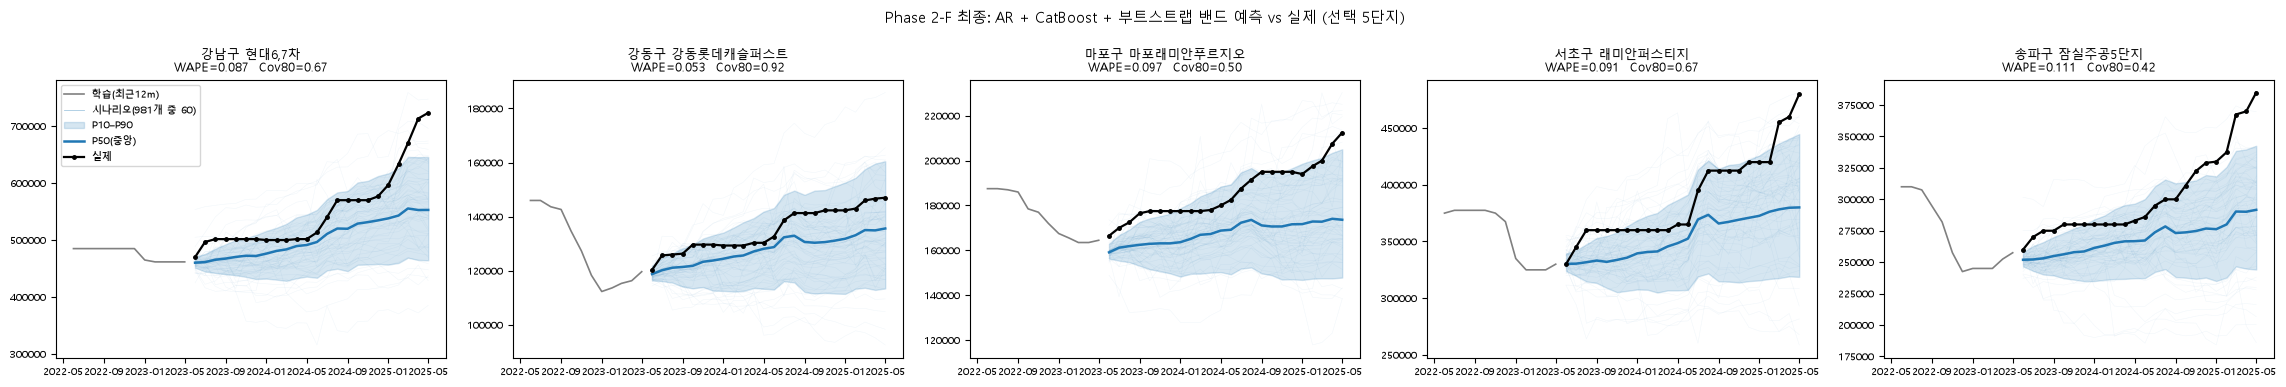

[phase2-F] 최종 결과 저장: module2/final_band_metrics.csv, final_fan_charts.png


In [ ]:
# ===== Phase 2-F. 최종 결과: B* + CatBoost + 부트스트랩 (After) =====
_metrics = ["RMSE", "WAPE", "Pinball", "Winkler", "Cover80", "CRPS"]
final_df = after_df[_metrics].copy()
_mean_row = pd.DataFrame(final_df.mean().to_dict(), index=["■ 평균(5단지)"])
final_out = pd.concat([final_df, _mean_row])

print(f"=== 최종 밴드 예측 성능: {B_STAR} + CatBoost + 부트스트랩 (5개 단지) ===")
print(final_out.round(4).to_string())
print("  · RMSE/WAPE/Pinball/Winkler/CRPS = 작을수록 좋음   · Cover80 = 명목 0.80 근접이 이상적")
final_out.round(4).to_csv(os.path.join(CFG.OUT_ROOT, "module2", "final_band_metrics.csv"), encoding="utf-8-sig")

# ===== 트렌드(팬)차트: 최종 After — 시나리오 경로 + P10/P50/P90 + 실제 (선택 5단지) =====
N_SHOW_PATHS = 60                       # 서브플롯당 흐릿하게 표시할 경로 수
_rng_paths = np.random.default_rng(CFG.BOOTSTRAP_SEED)
n = len(series_store)
fig, axes = plt.subplots(1, n, figsize=(4.6 * n, 3.9), squeeze=False)
for col, (key, st) in enumerate(series_store.items()):
    ax = axes[0][col]; r = after_results[key]
    x = pd.to_datetime(r["dates"])
    # 학습 꼬리(최근 12개월) 컨텍스트
    s_tr = get_target_series(st["train"]).iloc[-12:]
    ax.plot(s_tr.index, s_tr.values, color="0.5", lw=1.2, label="학습(최근12m)")
    # 생성된 전체 예측 시나리오 — 흐릿한 선
    ens = r["ensemble"]                              # (n_keep, H) 원단위
    m_show = min(N_SHOW_PATHS, ens.shape[0])
    sel = _rng_paths.choice(ens.shape[0], size=m_show, replace=False)
    ax.plot(x, ens[sel].T, color="tab:blue", lw=0.4, alpha=0.06)
    ax.plot([], [], color="tab:blue", lw=0.6, alpha=0.4, label=f"시나리오({ens.shape[0]:,}개 중 {m_show})")
    ax.fill_between(x, r["P10"], r["P90"], color="tab:blue", alpha=0.18, label="P10–P90")
    ax.plot(x, r["P50"], color="tab:blue", lw=1.8, label="P50(중앙)")
    ax.plot(x, r["actual"], color="black", lw=1.6, marker="o", ms=2.5, label="실제")
    cov = coverage(r["actual"], r["P10"], r["P90"]); wp = wape(r["actual"], r["P50"])
    ax.set_title(f"{st['gu']} {st['name']}\nWAPE={wp:.3f}  Cov80={cov:.2f}", fontsize=9)
    ax.tick_params(labelsize=7)
axes[0][0].legend(fontsize=7, loc="upper left")
plt.suptitle(f"Phase 2-F 최종: {B_STAR} + CatBoost + 부트스트랩 밴드 예측 vs 실제 (선택 5단지)", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUT_ROOT, "module2", "final_fan_charts.png"), dpi=110, bbox_inches="tight")
plt.show()
print("[phase2-F] 최종 결과 저장: module2/final_band_metrics.csv, final_fan_charts.png")


# Phase 3. 설명 · 피처 선택 (SHAP)

전역 CatBoost 보정모델의 **SHAP 값**으로 어떤 피처가 h스텝 오차(=B\* 가 놓친 부분)를 설명하는지 본다.

- **SHAP Summary** : 피처별 기여 분포. 큰 |SHAP| = 보정에 중요.
- **피처 선택** : 정규화 평균 |SHAP| < `FEATURE_DROP_THRESHOLD`(0.5%) 인 저기여 피처는 제거 후보로 표시.
- CatBoost 네이티브 `get_feature_importance(type='ShapValues')` 사용 (범주형 안전·고속).

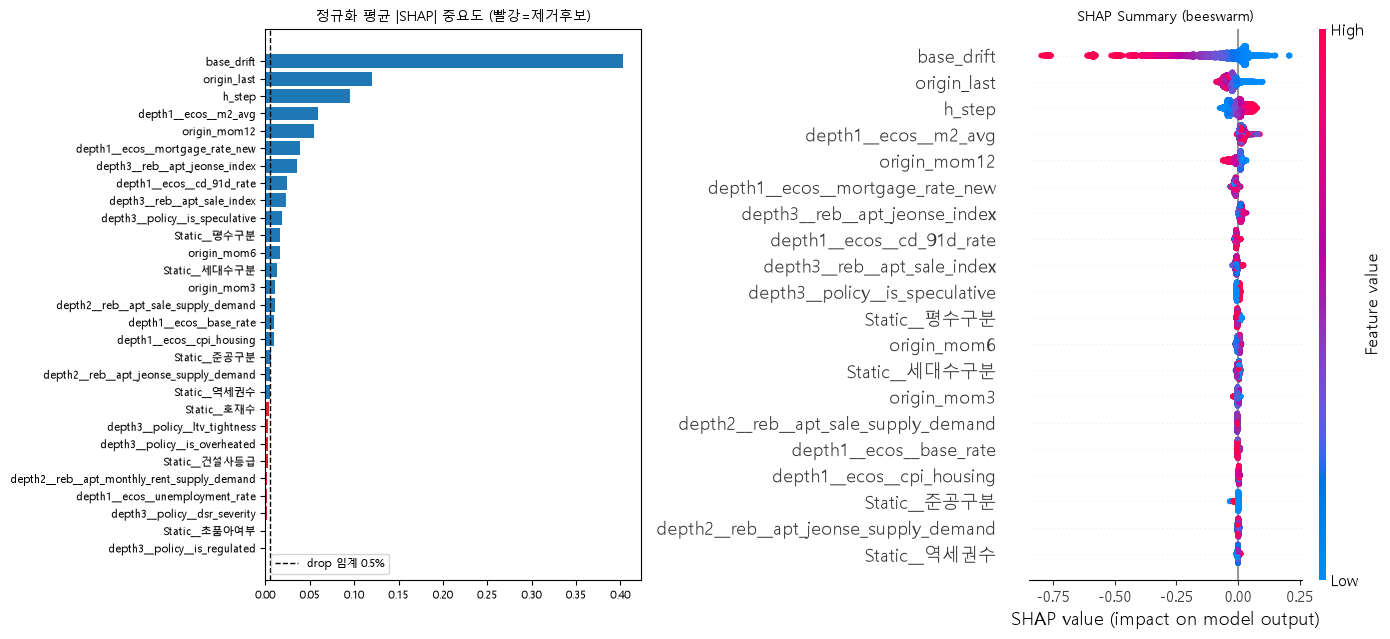

=== 피처 중요도 (정규화 평균 |SHAP|) ===
                                    feature  mean_abs_shap   norm  drop후보
                                 base_drift         0.1183 0.4034   False
                                origin_last         0.0351 0.1197   False
                                     h_step         0.0280 0.0957   False
                       depth1__ecos__m2_avg         0.0174 0.0594   False
                               origin_mom12         0.0161 0.0549   False
            depth1__ecos__mortgage_rate_new         0.0115 0.0394   False
              depth3__reb__apt_jeonse_index         0.0106 0.0361   False
                  depth1__ecos__cd_91d_rate         0.0072 0.0245   False
                depth3__reb__apt_sale_index         0.0069 0.0237   False
             depth3__policy__is_speculative         0.0056 0.0192   False
                               Static__평수구분         0.0049 0.0166   False
                                origin_mom6         0.0048 0.0163   False
       

In [ ]:
# ===== SHAP: 전역 CatBoost 보정모델 설명 + 피처선택 =====
_feat_names = list(X_tr.columns)
# 속도: 검증셋에서 표본추출
_rng = np.random.default_rng(CFG.CB_RANDOM_SEED)
_n_s = min(8000, len(X_va))
_idx = _rng.choice(len(X_va), size=_n_s, replace=False)
X_shap = X_va.iloc[_idx].reset_index(drop=True)
y_shap = y_va[_idx]
_shap = cb_model.get_feature_importance(Pool(X_shap, y_shap, cat_features=cat_idx), type="ShapValues")
shap_vals = _shap[:, :-1]                       # 마지막 열 = expected value 제외

# 정규화 평균 |SHAP| 중요도
imp = np.abs(shap_vals).mean(axis=0)
imp_norm = imp / imp.sum()
imp_df = pd.DataFrame({"feature": _feat_names, "mean_abs_shap": imp, "norm": imp_norm}) \
            .sort_values("norm", ascending=False).reset_index(drop=True)
imp_df["drop후보"] = imp_df["norm"] < CFG.FEATURE_DROP_THRESHOLD

fig, ax = plt.subplots(1, 2, figsize=(14, 6.5), gridspec_kw={"width_ratios": [1.1, 1]})
# (좌) 정규화 중요도 바
top = imp_df.iloc[::-1]
colors = ["tab:red" if d else "tab:blue" for d in top["drop후보"]]
ax[0].barh(top["feature"], top["norm"], color=colors)
ax[0].axvline(CFG.FEATURE_DROP_THRESHOLD, color="k", ls="--", lw=1,
              label=f"drop 임계 {CFG.FEATURE_DROP_THRESHOLD:.1%}")
ax[0].set_title("정규화 평균 |SHAP| 중요도 (빨강=제거후보)", fontsize=10)
ax[0].tick_params(labelsize=8); ax[0].legend(fontsize=8)
# (우) beeswarm — 범주형은 코드로 인코딩해 색상화
try:
    import shap as _shaplib
    X_enc = X_shap.copy()
    for c in CAT_FEATS:
        X_enc[c] = X_enc[c].astype("category").cat.codes
    plt.sca(ax[1])
    _shaplib.summary_plot(shap_vals, X_enc, feature_names=_feat_names, show=False, plot_size=None)
    ax[1].set_title("SHAP Summary (beeswarm)", fontsize=10)
except Exception as e:
    ax[1].text(0.5, 0.5, f"beeswarm 생략\n{e}", ha="center", va="center"); ax[1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUT_ROOT, "module3", "shap_summary.png"), dpi=110, bbox_inches="tight")
plt.show()

print("=== 피처 중요도 (정규화 평균 |SHAP|) ===")
print(imp_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
_drop = imp_df.loc[imp_df["drop후보"], "feature"].tolist()
print(f"\n[phase3] 제거후보({CFG.FEATURE_DROP_THRESHOLD:.1%} 미만) {len(_drop)}개: {_drop}")
imp_df.to_csv(os.path.join(CFG.OUT_ROOT, "module3", "feature_importance_shap.csv"), encoding="utf-8-sig")
print("[phase3] 저장: module3/shap_summary.png, feature_importance_shap.csv")
